# Phase 2.1: Analisis Statistik Individu (Per Subjek)

**Tujuan:**  
Menganalisis pola metrik konektivitas graf tiap subjek secara terpisah untuk ketiga kelas emosi (*negative*, *neutral*, *positive*). Analisis ini menghasilkan:
1. **Line Plot** — pola tiap subjek lintas emosi
2. **Bar Plot** — perbandingan 6 metrik per subjek, dikelompokkan berdasarkan emosi
3. **Z-Score Heatmap** — deteksi anomali/pola outlier antar subjek
4. **CSV Statistik Individual** — tabel mean ± std per subjek per kelas emosi

---

In [1]:
# ==============================================================================
# SECTION 0: IMPORT LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
print('Libraries imported')

Libraries imported


In [2]:
# ==============================================================================
# SECTION 1: KONFIGURASI GLOBAL
# ==============================================================================
# Input: CSV dari Phase 1 (kolom nama metrik menggunakan prefiks gc_ / pdc_xxx_)
PHASE1_DIR = Path(r'D:\Skripsi\new_data\phase_1_data_structuring\csv')
OUTPUT_DIR = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\output')
FIG_DIR    = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# NOTE: 'class_label' berisi teks emosi: 'negative'/'neutral'/'positive'
#       'class'       berisi kode numerik: 0/1/2
CLASS_COL  = 'class_label'   # Gunakan ini untuk grouping & plotting
EMOTIONS   = ['negative', 'neutral', 'positive']
PALETTE    = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}

# Semua dataset: GC + 6 pita frekuensi PDC
DATASETS = {
    'GC':           PHASE1_DIR / 'cleaned_graph_metrics_gc.csv',
    'PDC Delta':    PHASE1_DIR / 'cleaned_graph_metrics_pdc_delta.csv',
    'PDC Theta':    PHASE1_DIR / 'cleaned_graph_metrics_pdc_theta.csv',
    'PDC Alpha':    PHASE1_DIR / 'cleaned_graph_metrics_pdc_alpha.csv',
    'PDC Beta':     PHASE1_DIR / 'cleaned_graph_metrics_pdc_beta.csv',
    'PDC Gamma':    PHASE1_DIR / 'cleaned_graph_metrics_pdc_gamma.csv',
    'PDC Broadband':PHASE1_DIR / 'cleaned_graph_metrics_pdc_broadband.csv',
}

# ==============================================================================
# Load + strip prefiks kolom agar menjadi nama generik (mean_out_degree, dll.)
# ==============================================================================
data = {}
for name, csv_path in DATASETS.items():
    if not csv_path.exists():
        print(f'  [SKIP] {name}: file not found -> {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    
    # Deteksi prefiks (gc_ atau pdc_alpha_, dsb.) lalu strip agar generik
    prefix = 'gc' if name == 'GC' else f"pdc_{name.lower().split()[-1]}"
    df = df.rename(columns={
        col: col.replace(f'{prefix}_', '', 1)
        for col in df.columns if col.startswith(f'{prefix}_')
    })
    data[name] = df
    print(f'  Loaded {name}: {df.shape} | class_label: {sorted(df[CLASS_COL].unique())}')

# Kolom metrik yang akan digunakan
MEAN_COLS = ['mean_out_degree', 'mean_in_degree', 'mean_total_degree',
             'mean_out_strength', 'mean_in_strength', 'mean_total_strength']
SHORT = {
    'mean_out_degree': 'Out Degree', 'mean_in_degree': 'In Degree',
    'mean_total_degree': 'Total Degree', 'mean_out_strength': 'Out Strength',
    'mean_in_strength': 'In Strength', 'mean_total_strength': 'Total Strength'
}
print(f'\nOutput dir : {OUTPUT_DIR}')
print(f'Figures dir: {FIG_DIR}')

  Loaded GC: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Delta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Theta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Alpha: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Beta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Gamma: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Broadband: (675, 4047) | class_label: ['negative', 'neutral', 'positive']

Output dir : D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\output
Figures dir: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures


---
## Section 2: Line Plot Per Individu (Tiap Metrik, Tiap Metode)
Setiap subplot menampilkan 1 metrik. Setiap garis = 1 subjek, warna berbeda untuk tiap subjek.
Cocok untuk mengamati **pola perubahan lintas emosi** secara konsisten/anomali antar individu.


>>> Plotting: GC
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\gc_individual_lines.png


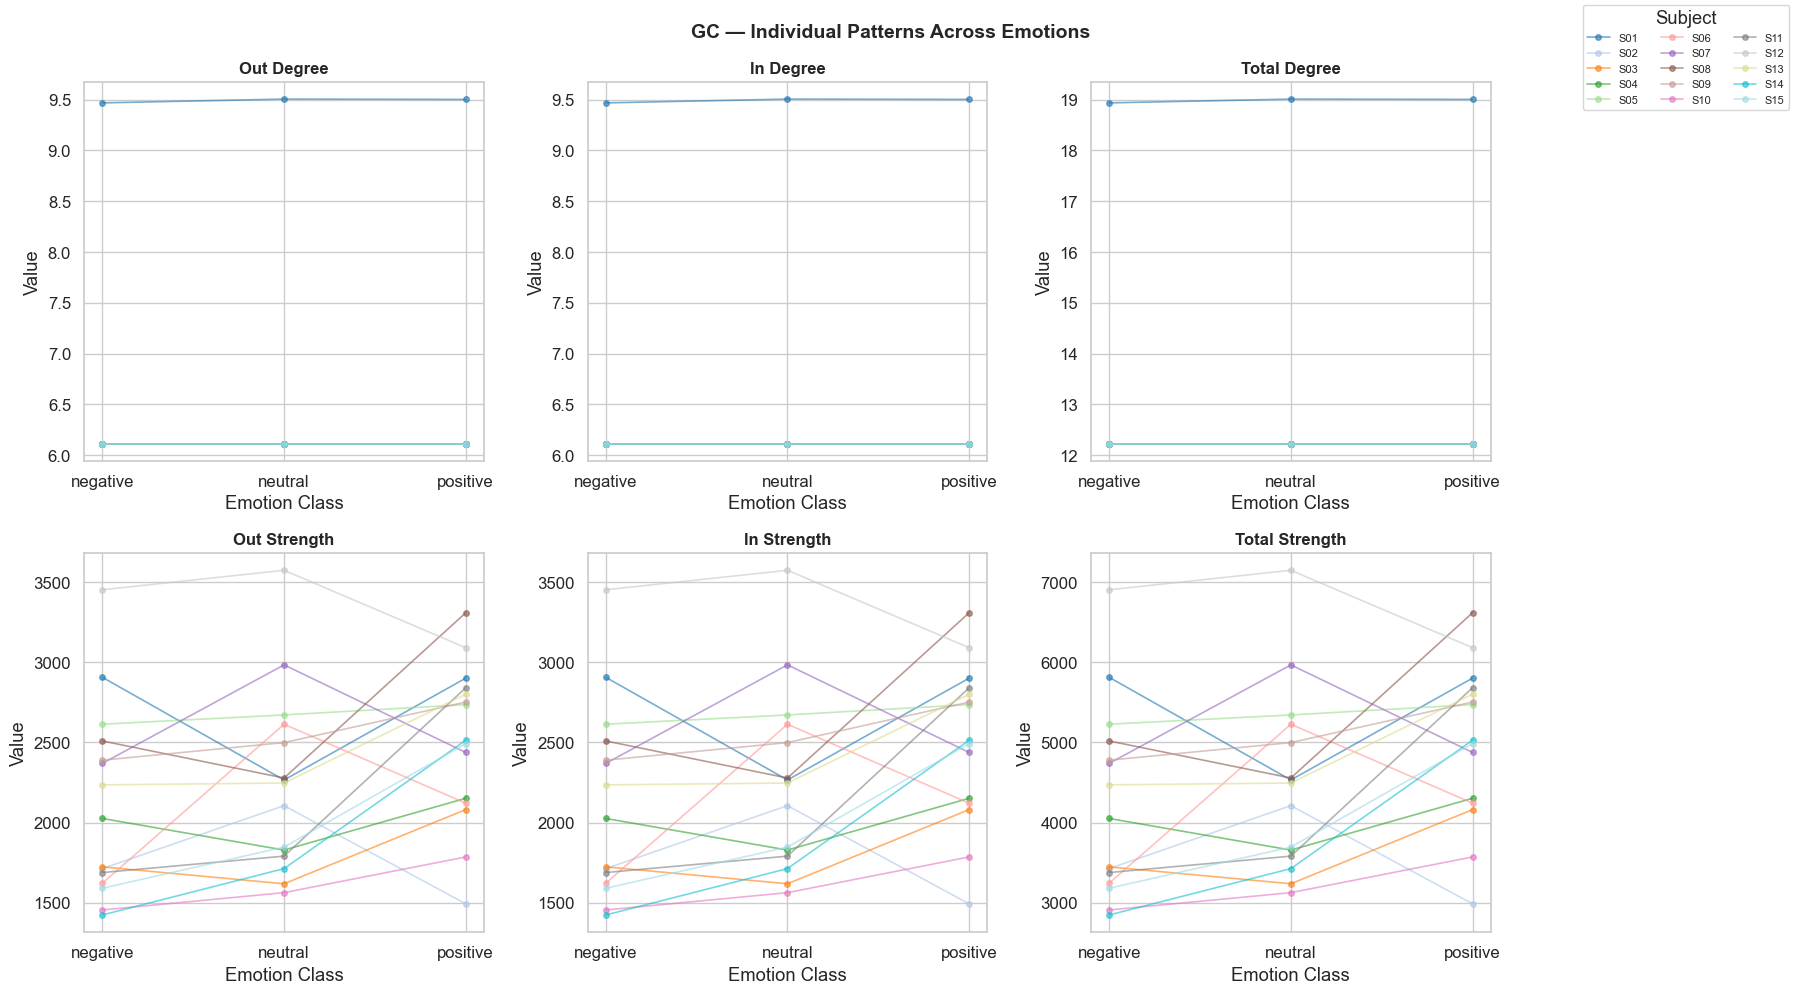


>>> Plotting: PDC Delta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_delta_individual_lines.png


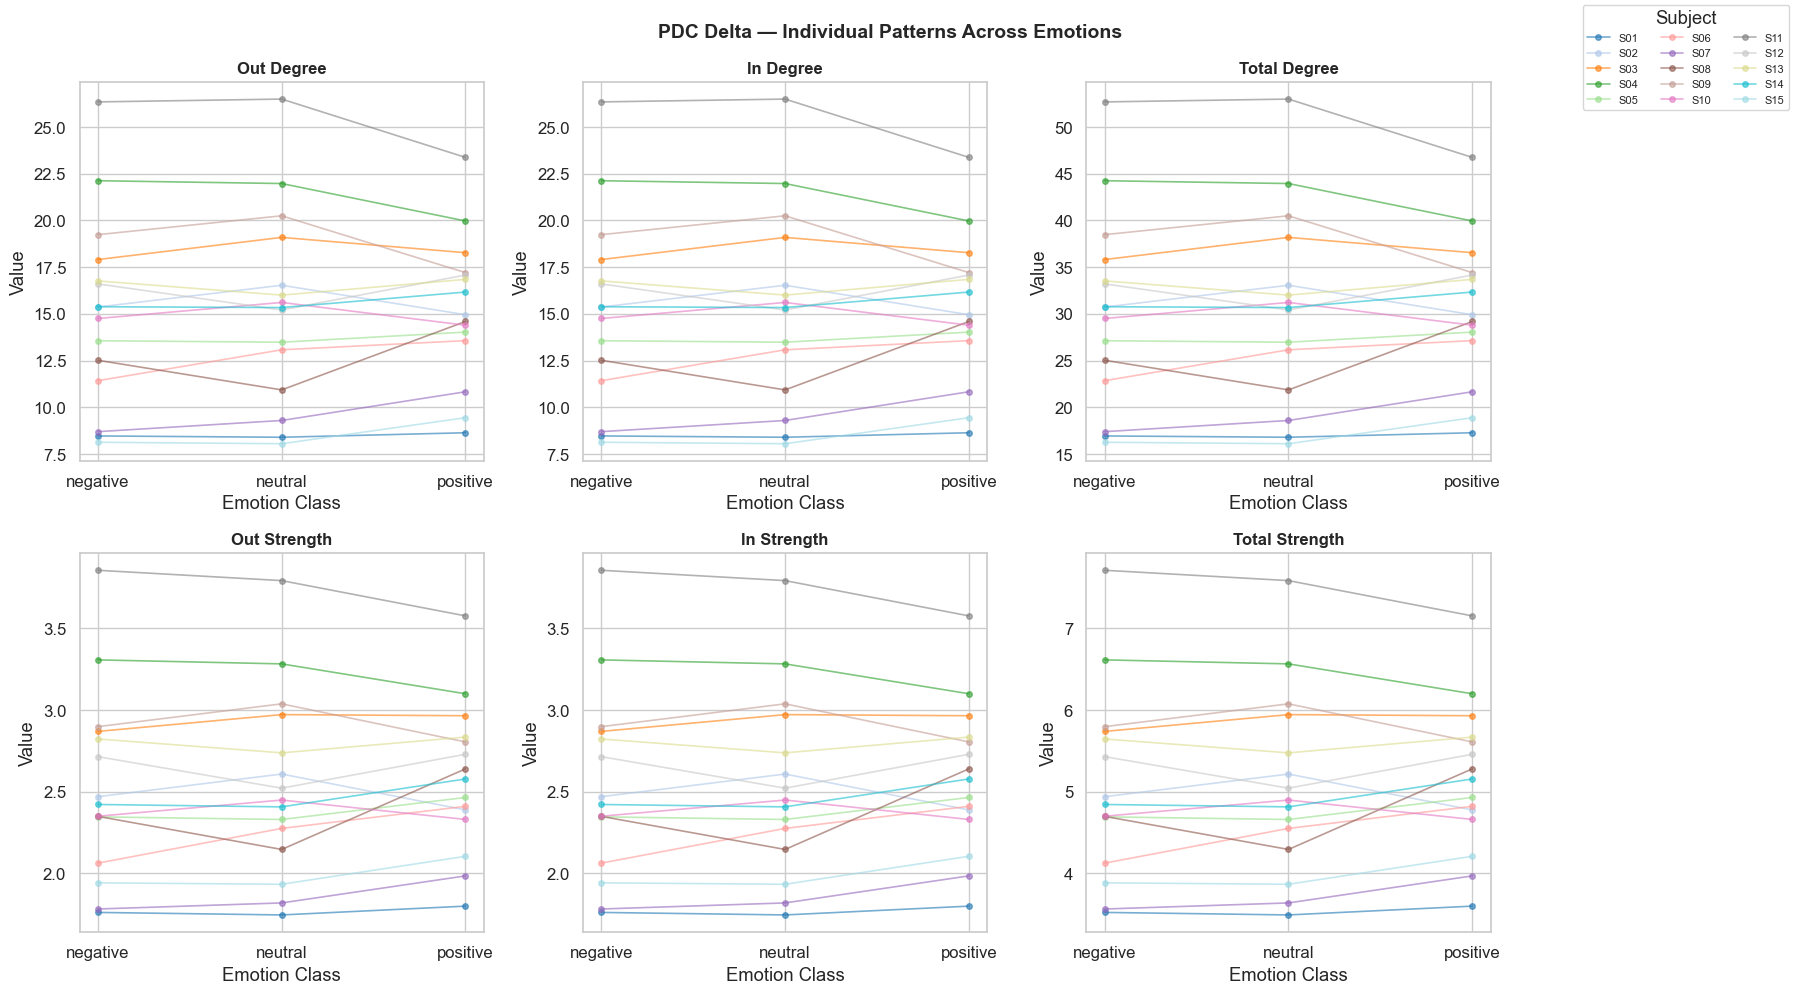


>>> Plotting: PDC Theta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_theta_individual_lines.png


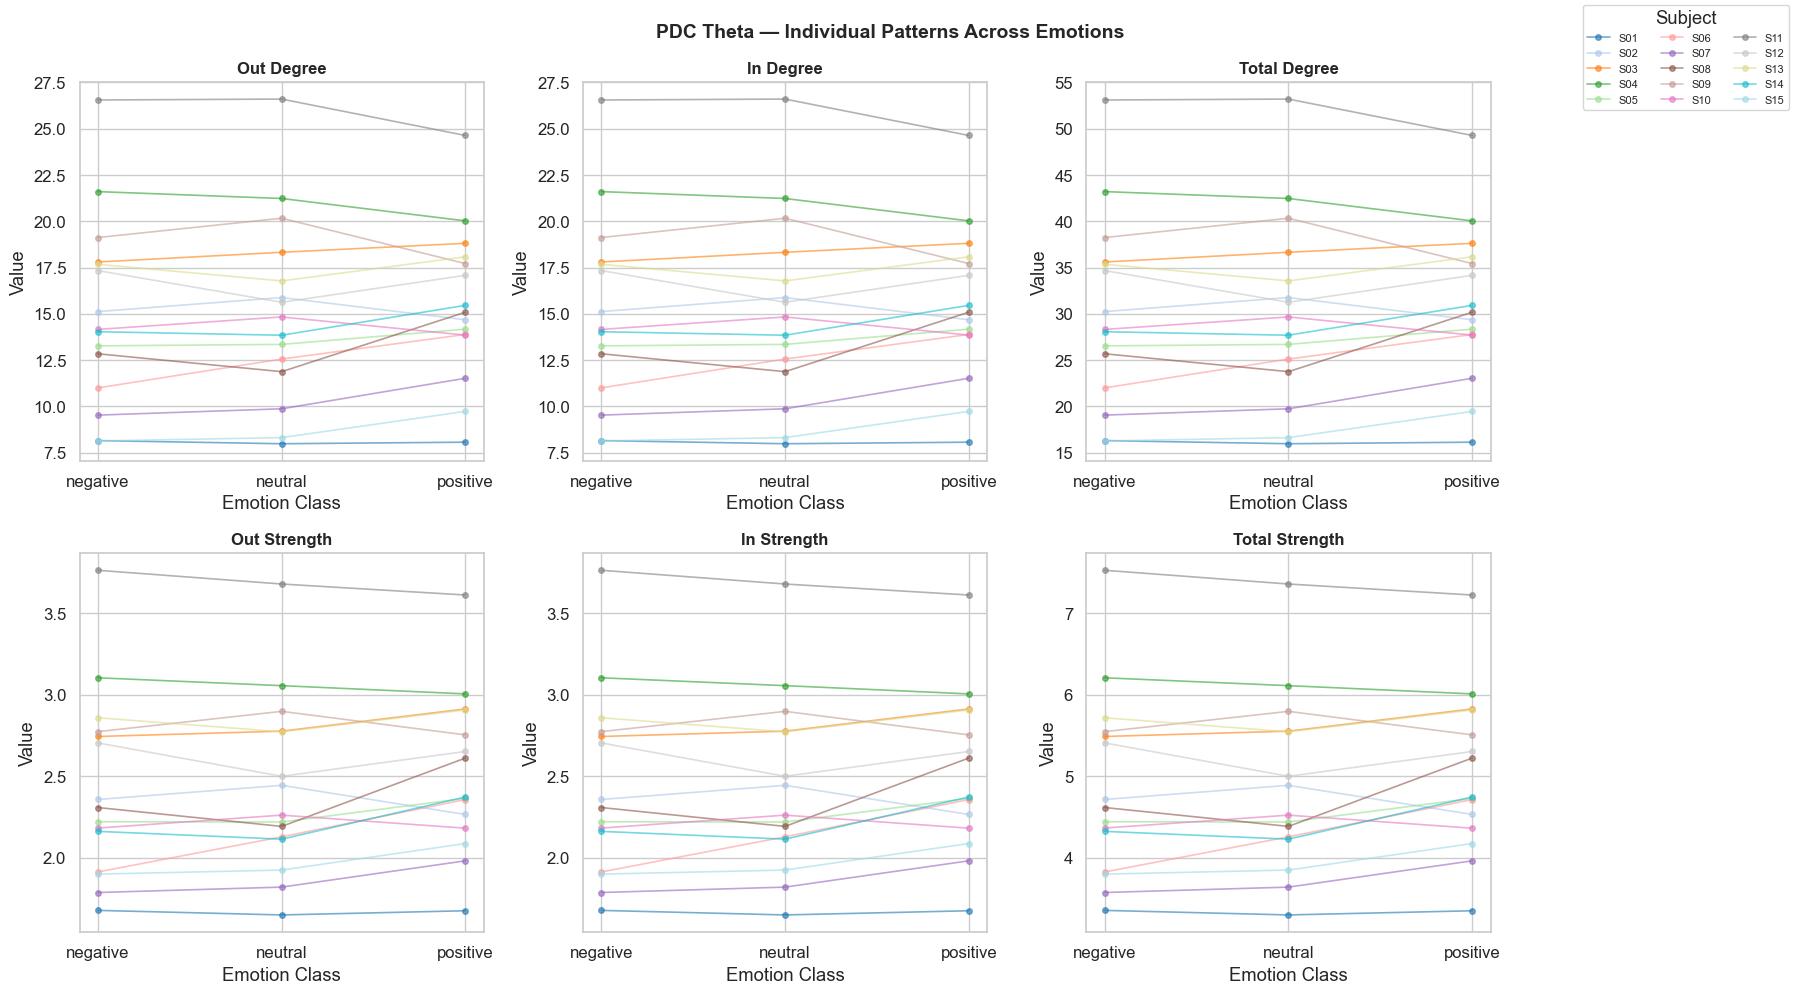


>>> Plotting: PDC Alpha
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_alpha_individual_lines.png


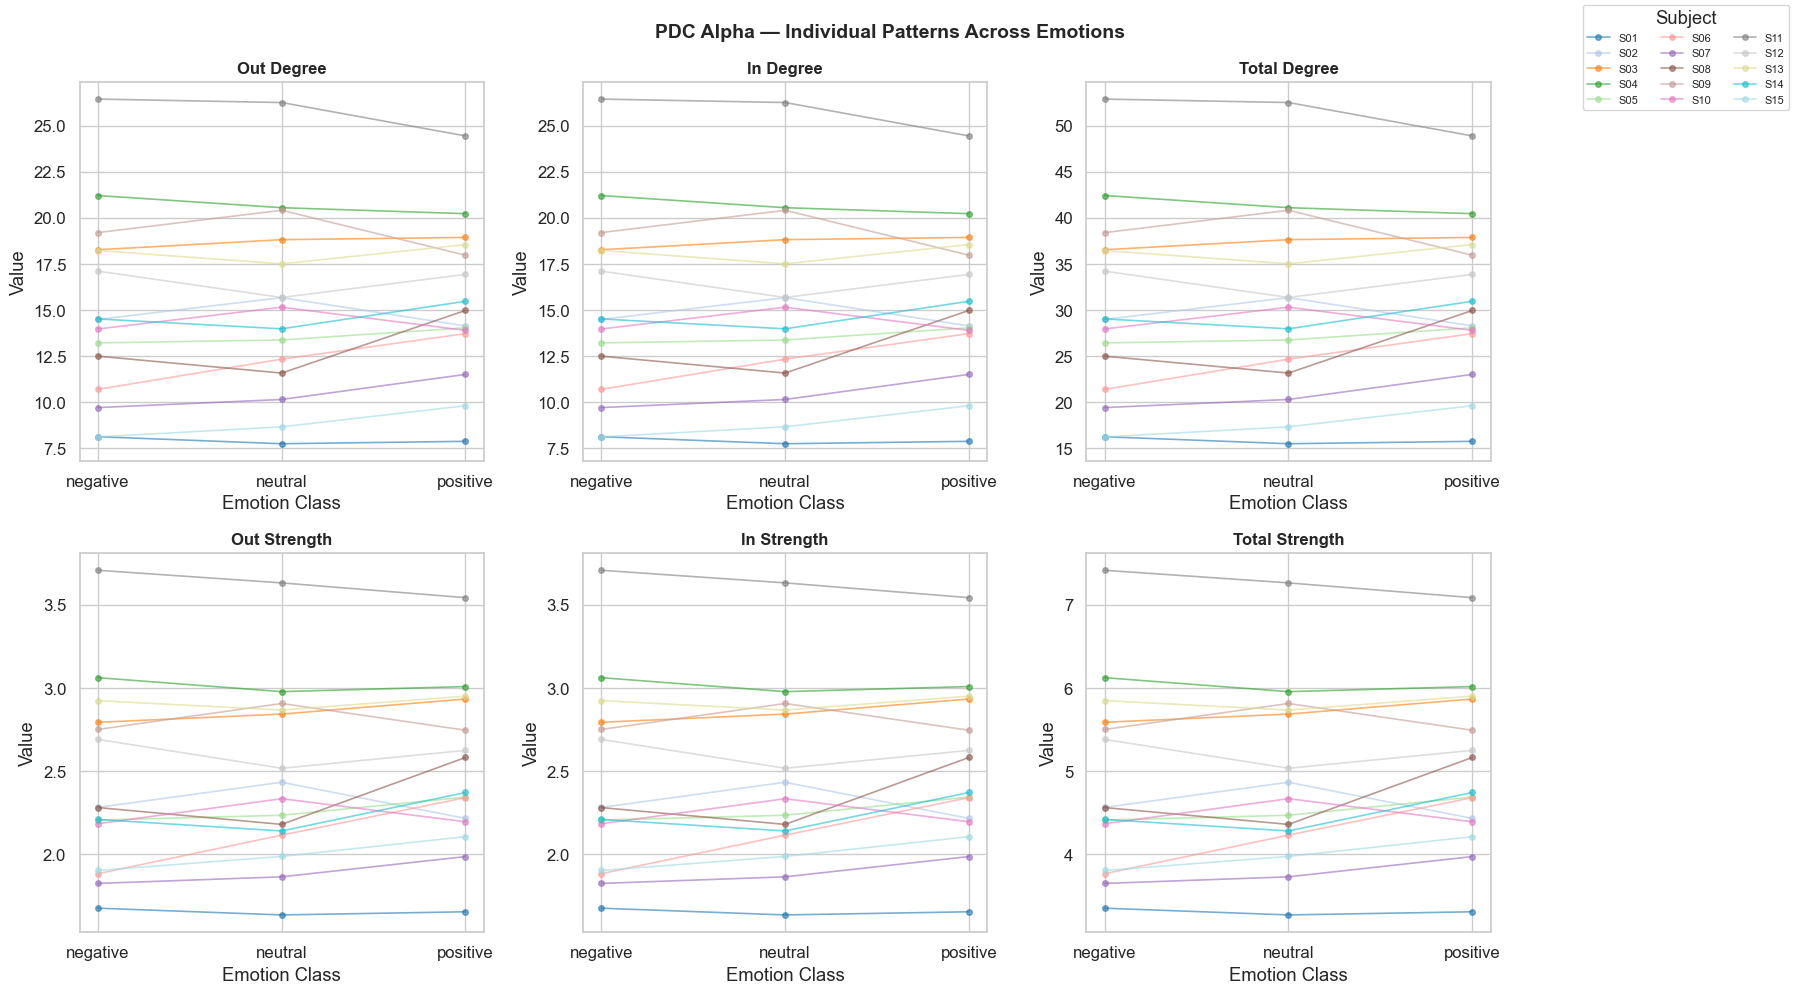


>>> Plotting: PDC Beta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_beta_individual_lines.png


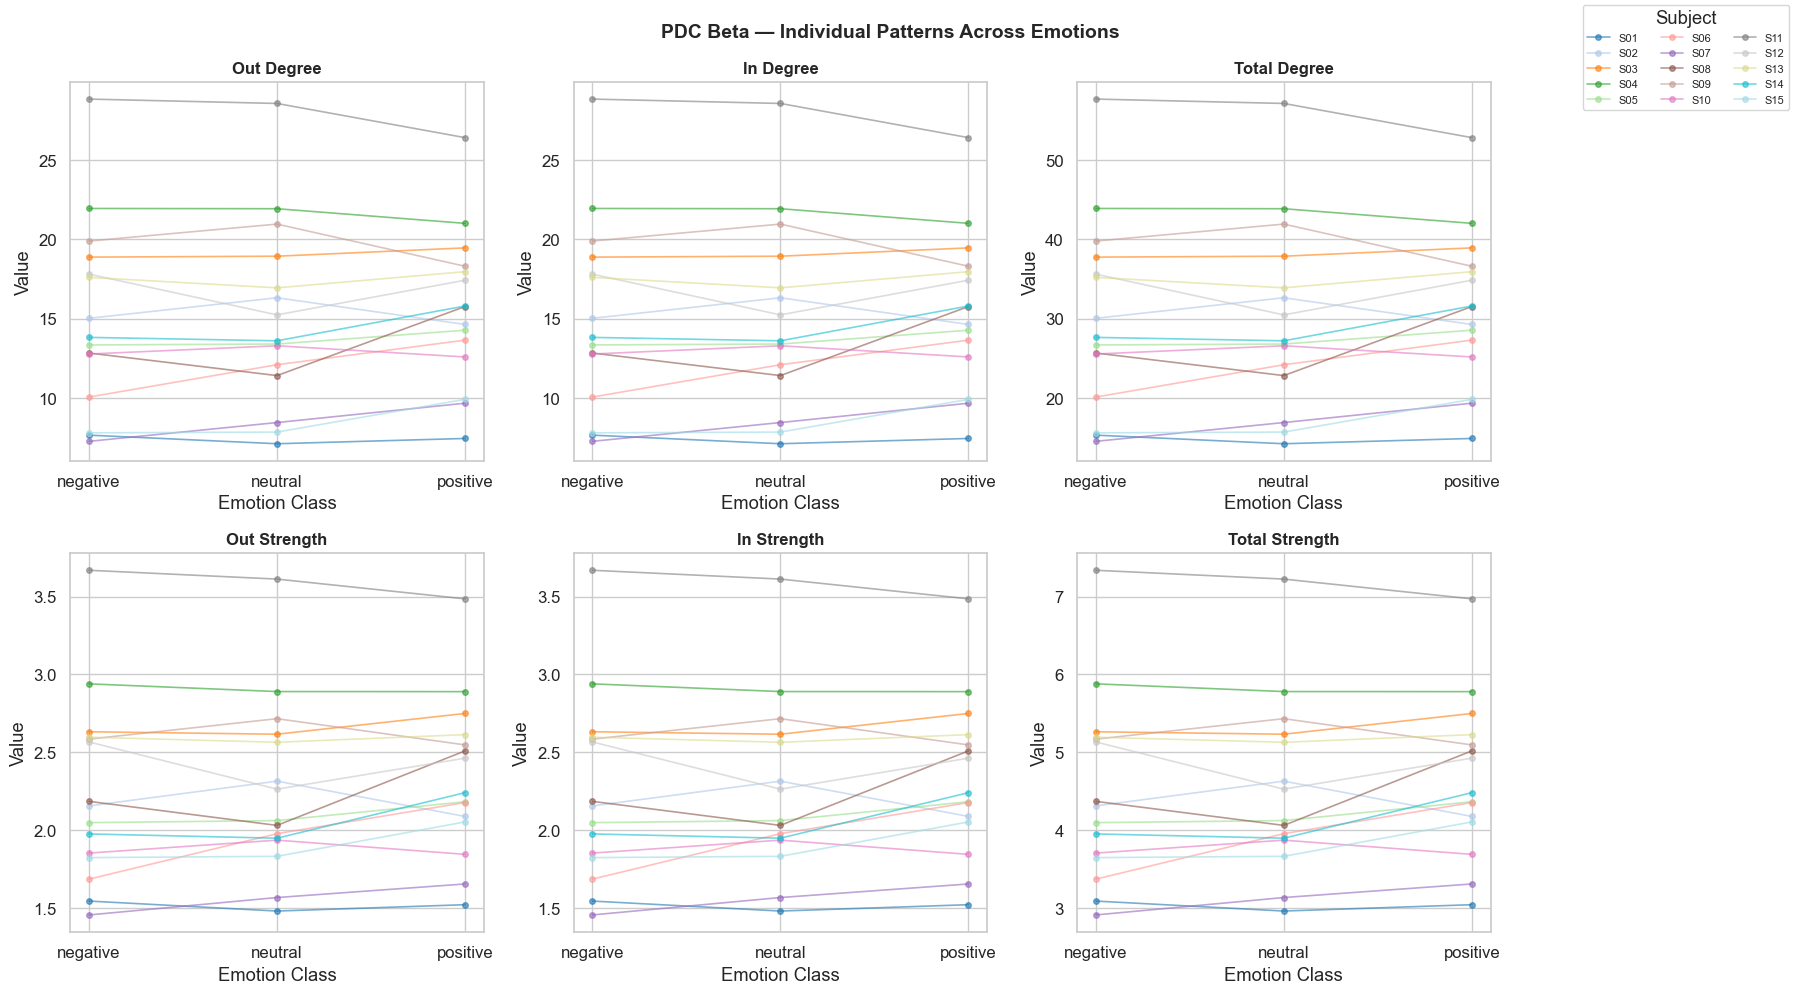


>>> Plotting: PDC Gamma
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_gamma_individual_lines.png


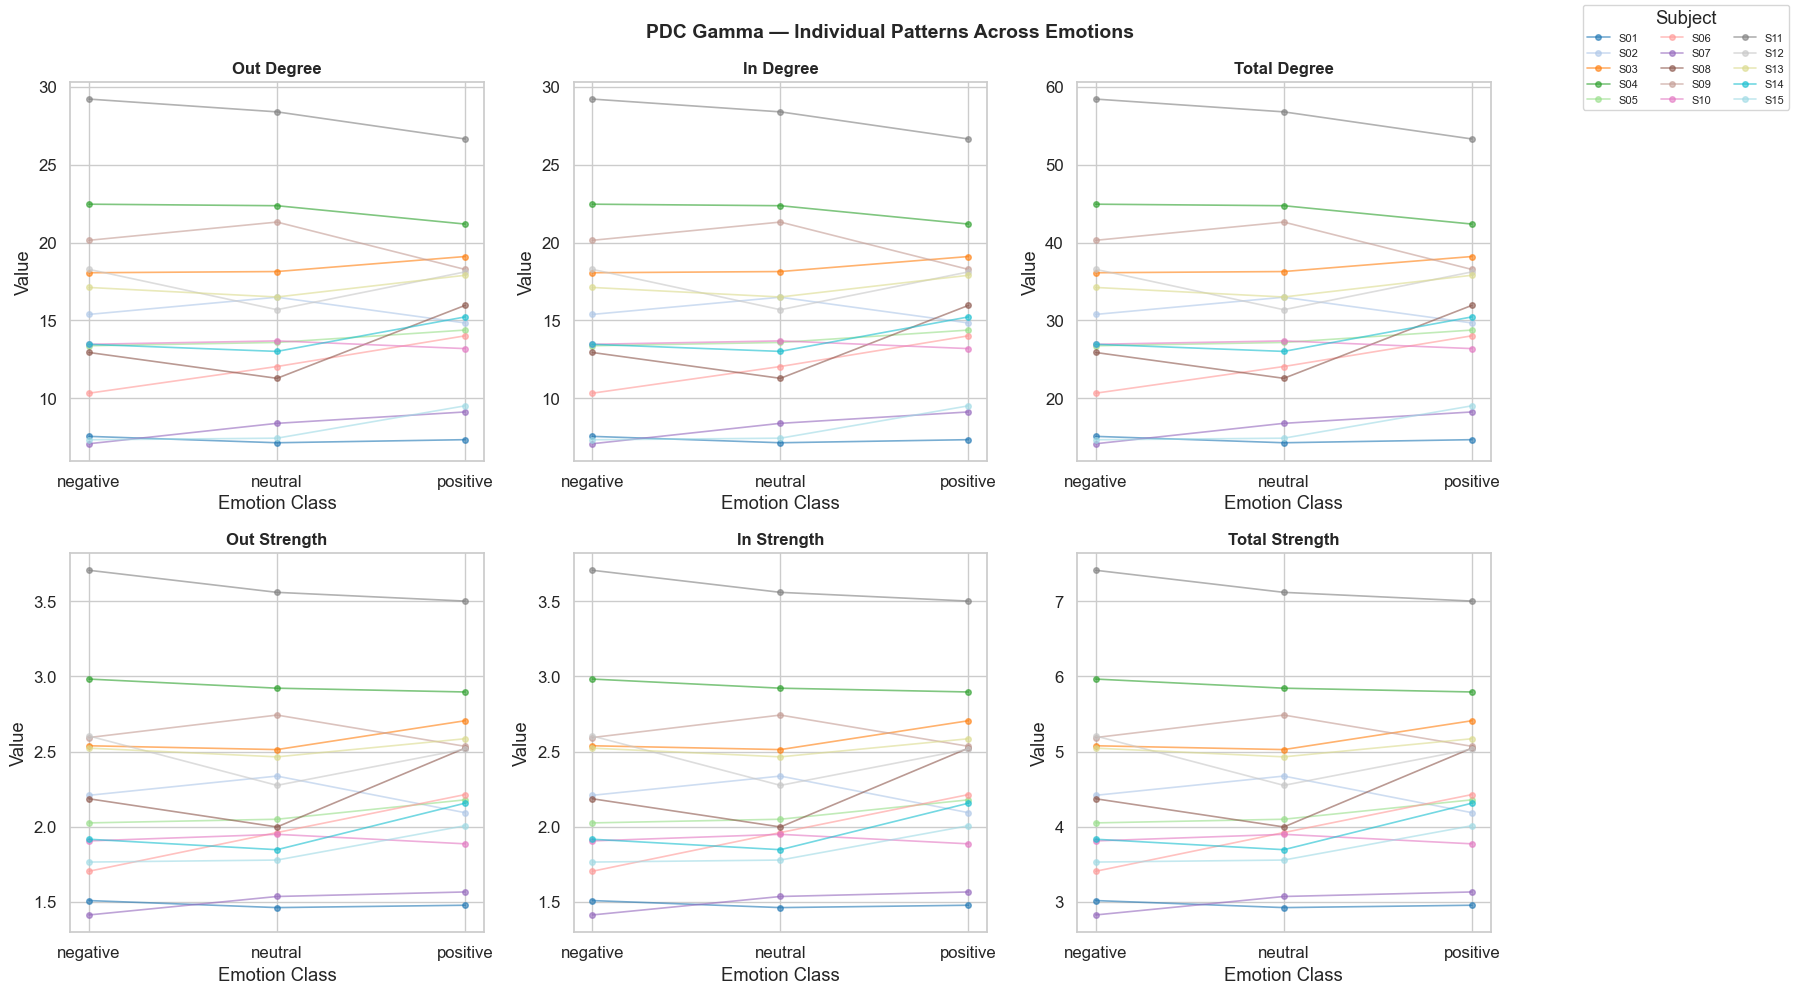


>>> Plotting: PDC Broadband
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_broadband_individual_lines.png


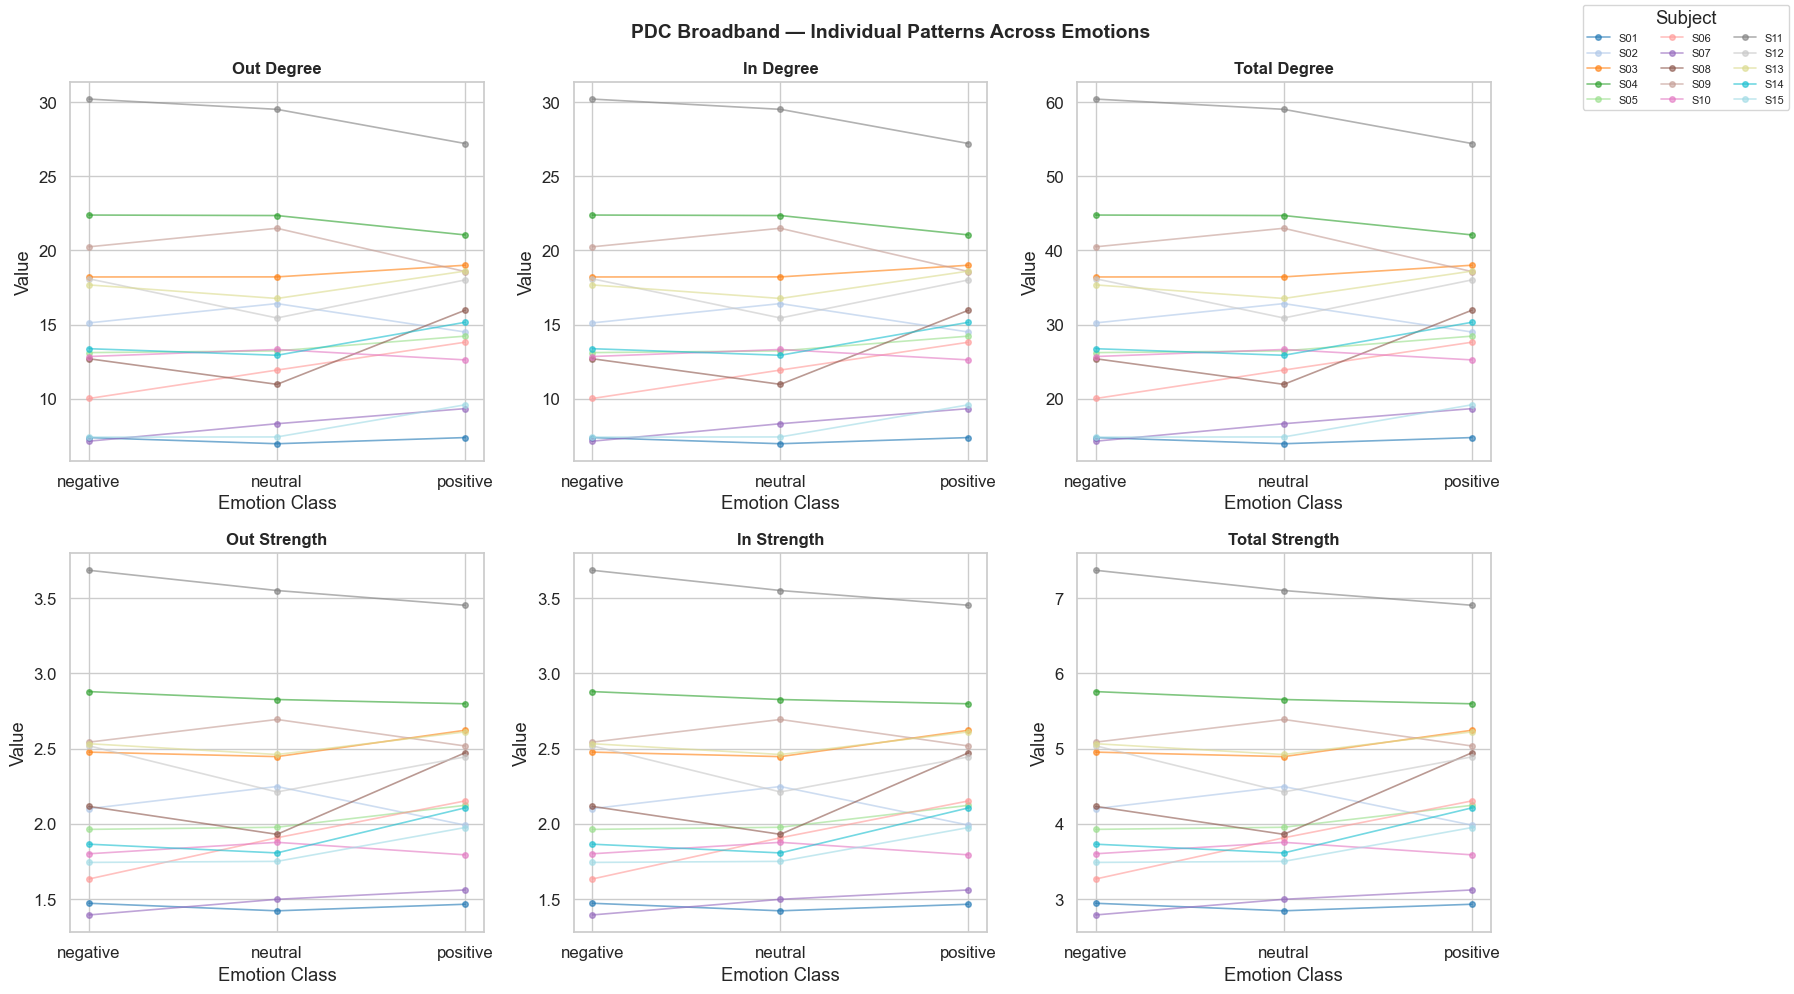

In [3]:
# ==============================================================================
# SECTION 2: LINE PLOT PER SUBJEK (tiap metrik, lintas emosi)
# ==============================================================================
def plot_individual_lines(df, method_name, save_prefix):
    # Rata-ratakan per subjek per kelas emosi
    df_avg = df.groupby(['subject_id', CLASS_COL])[MEAN_COLS].mean().reset_index()
    subjects = sorted(df_avg['subject_id'].unique())
    
    # Figure is placed at full \textwidth in the thesis; fonts are sized
    # for that print width (see connectome_plot.py fix for the same issue
    # on the topomap figures) rather than for a full-screen preview.
    cmap = plt.cm.get_cmap('tab20', len(subjects))
    fig, axes = plt.subplots(2, 3, figsize=(24, 13))
    axes = axes.flatten()
    
    for idx, col in enumerate(MEAN_COLS):
        ax = axes[idx]
        for s_idx, subj in enumerate(subjects):
            subj_data = (
                df_avg[df_avg['subject_id'] == subj]
                .set_index(CLASS_COL)
                .reindex(EMOTIONS)[col]
            )
            ax.plot(EMOTIONS, subj_data.values, marker='o',
                    alpha=0.7, linewidth=2.2, markersize=8,
                    color=cmap(s_idx), label=subj)
        
        ax.set_title(SHORT[col], fontsize=24, fontweight='bold')
        ax.set_xlabel('Emotion Class', fontsize=19)
        ax.set_ylabel('Value', fontsize=19)
        ax.tick_params(axis='both', labelsize=17)
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=2, fontsize=16, title='Subject',
               title_fontsize=17)
    fig.suptitle(f'{method_name} — Individual Patterns Across Emotions',
                 fontsize=28, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    
    path = FIG_DIR / f'{save_prefix}_individual_lines.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')
    plt.show()

for name, df in data.items():
    print(f'\n>>> Plotting: {name}')
    plot_individual_lines(df, name, name.lower().replace(' ', '_'))

---
## Section 3: Bar Plot Per Subjek (Grouped by Emotion)
Setiap subplot = 1 subjek (S01–S15). Menampilkan 6 metrik dikelompokkan berdasarkan 3 kelas emosi.
Cocok untuk membandingkan **profil konektivitas antar emosi** secara visual per individu.


>>> Plotting: GC
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\gc_subject_bars.png


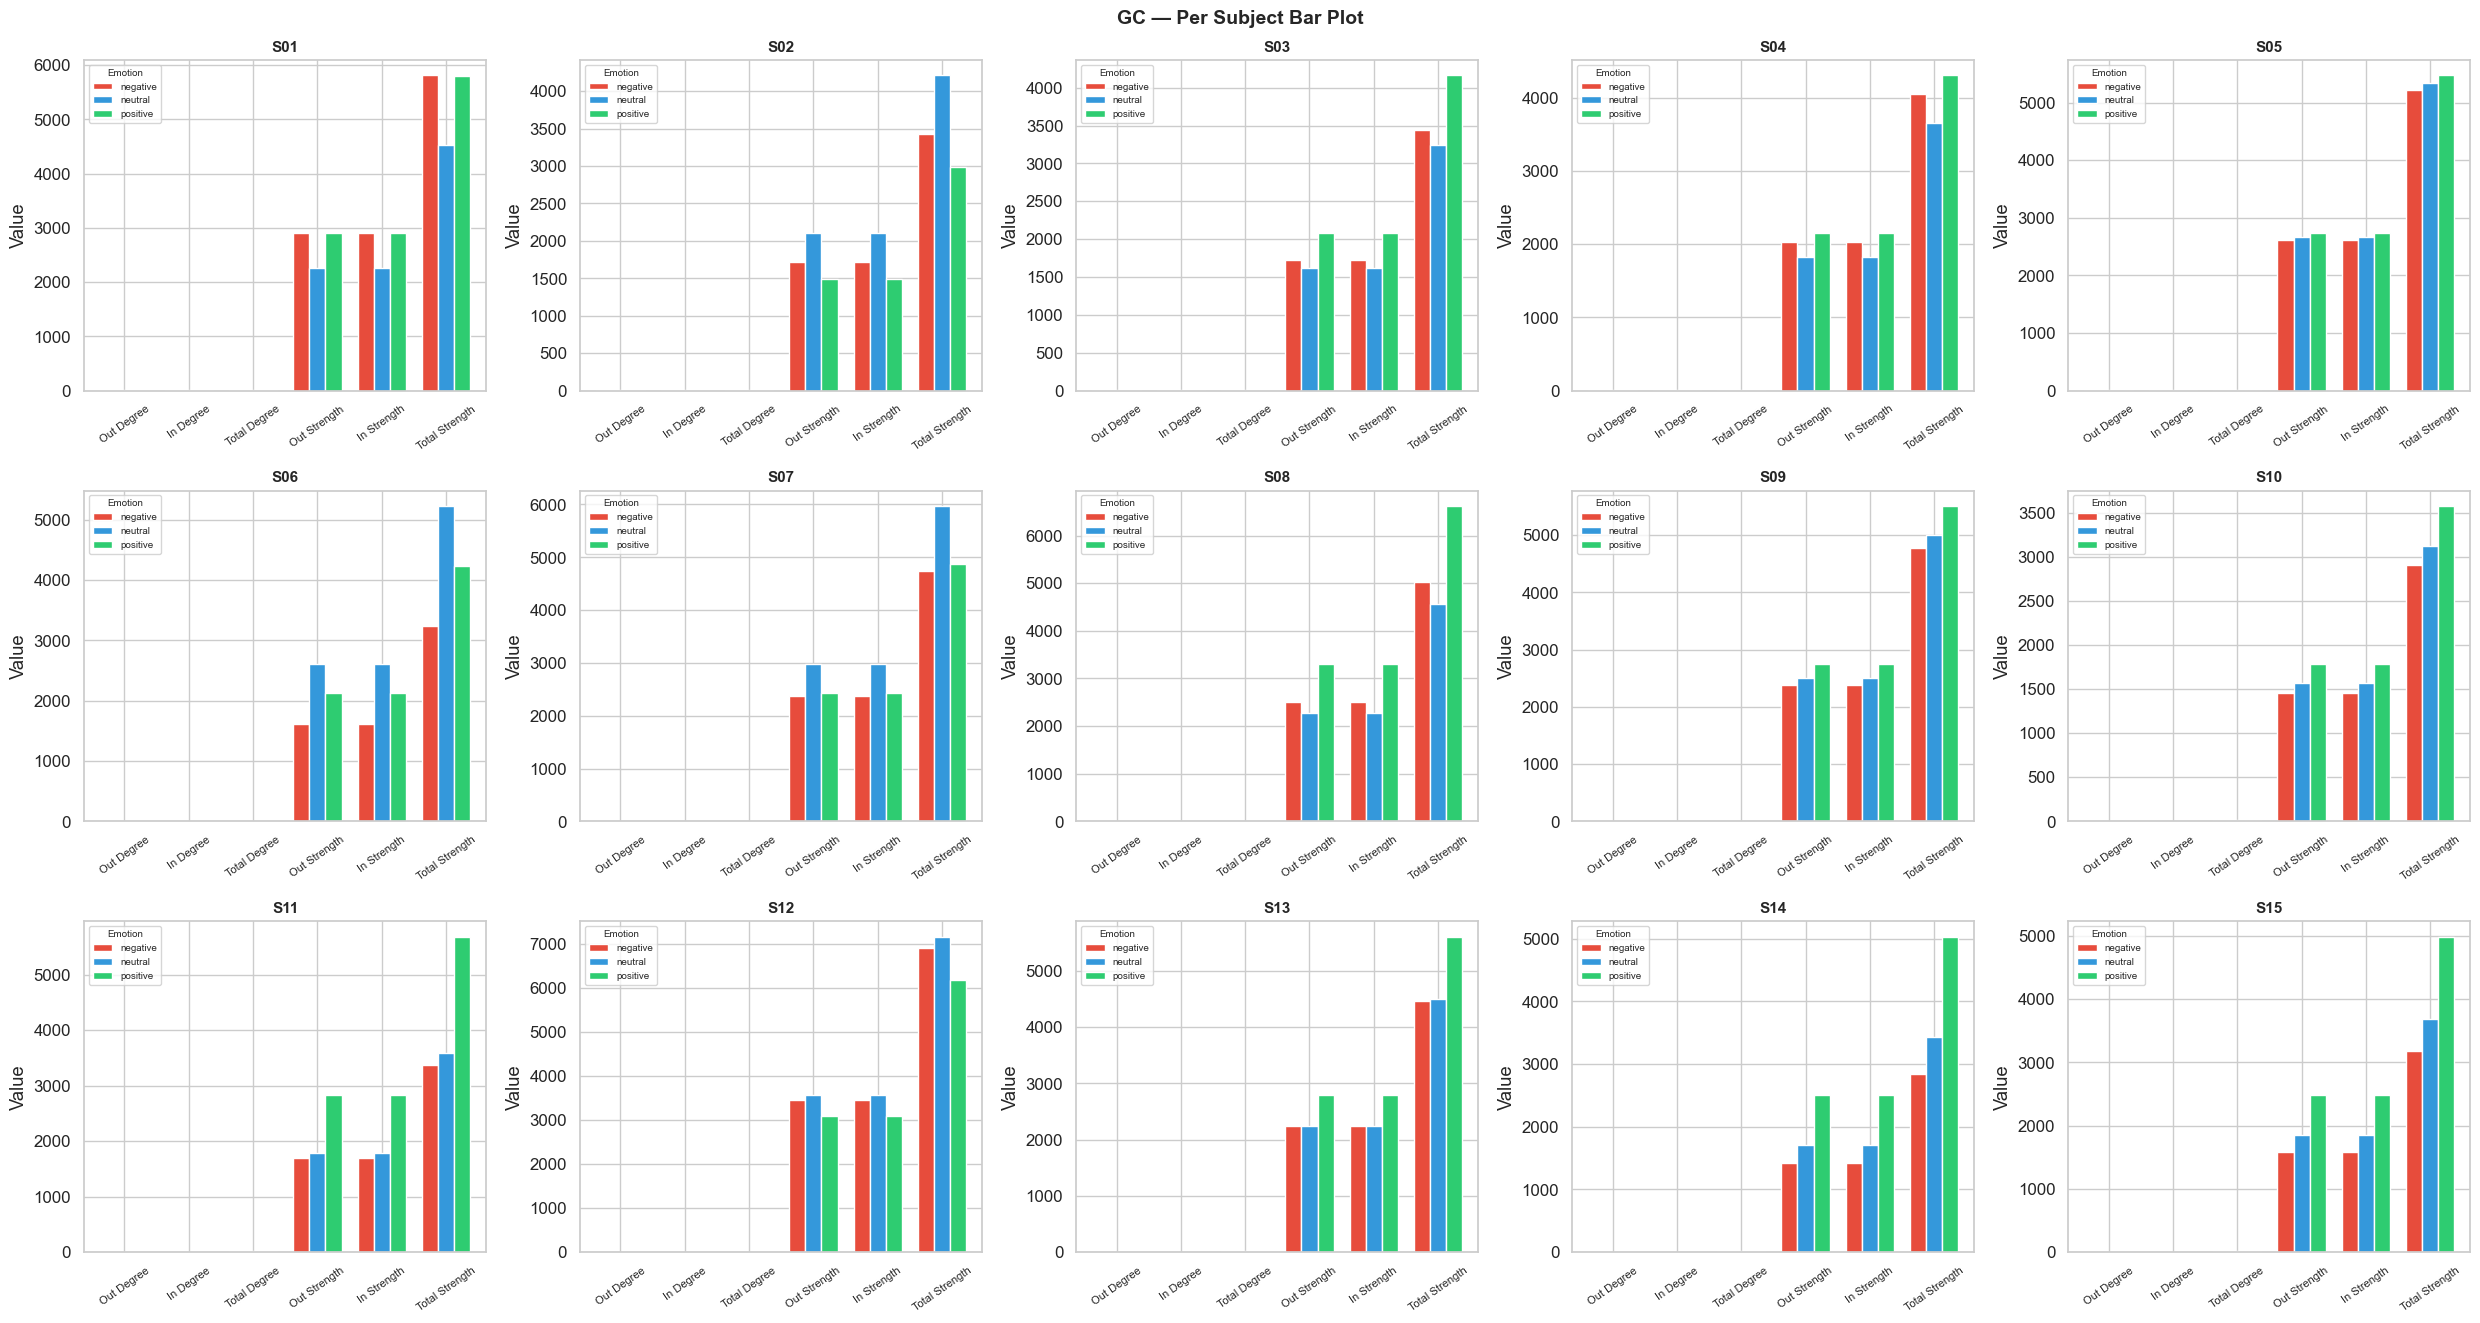


>>> Plotting: PDC Delta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_delta_subject_bars.png


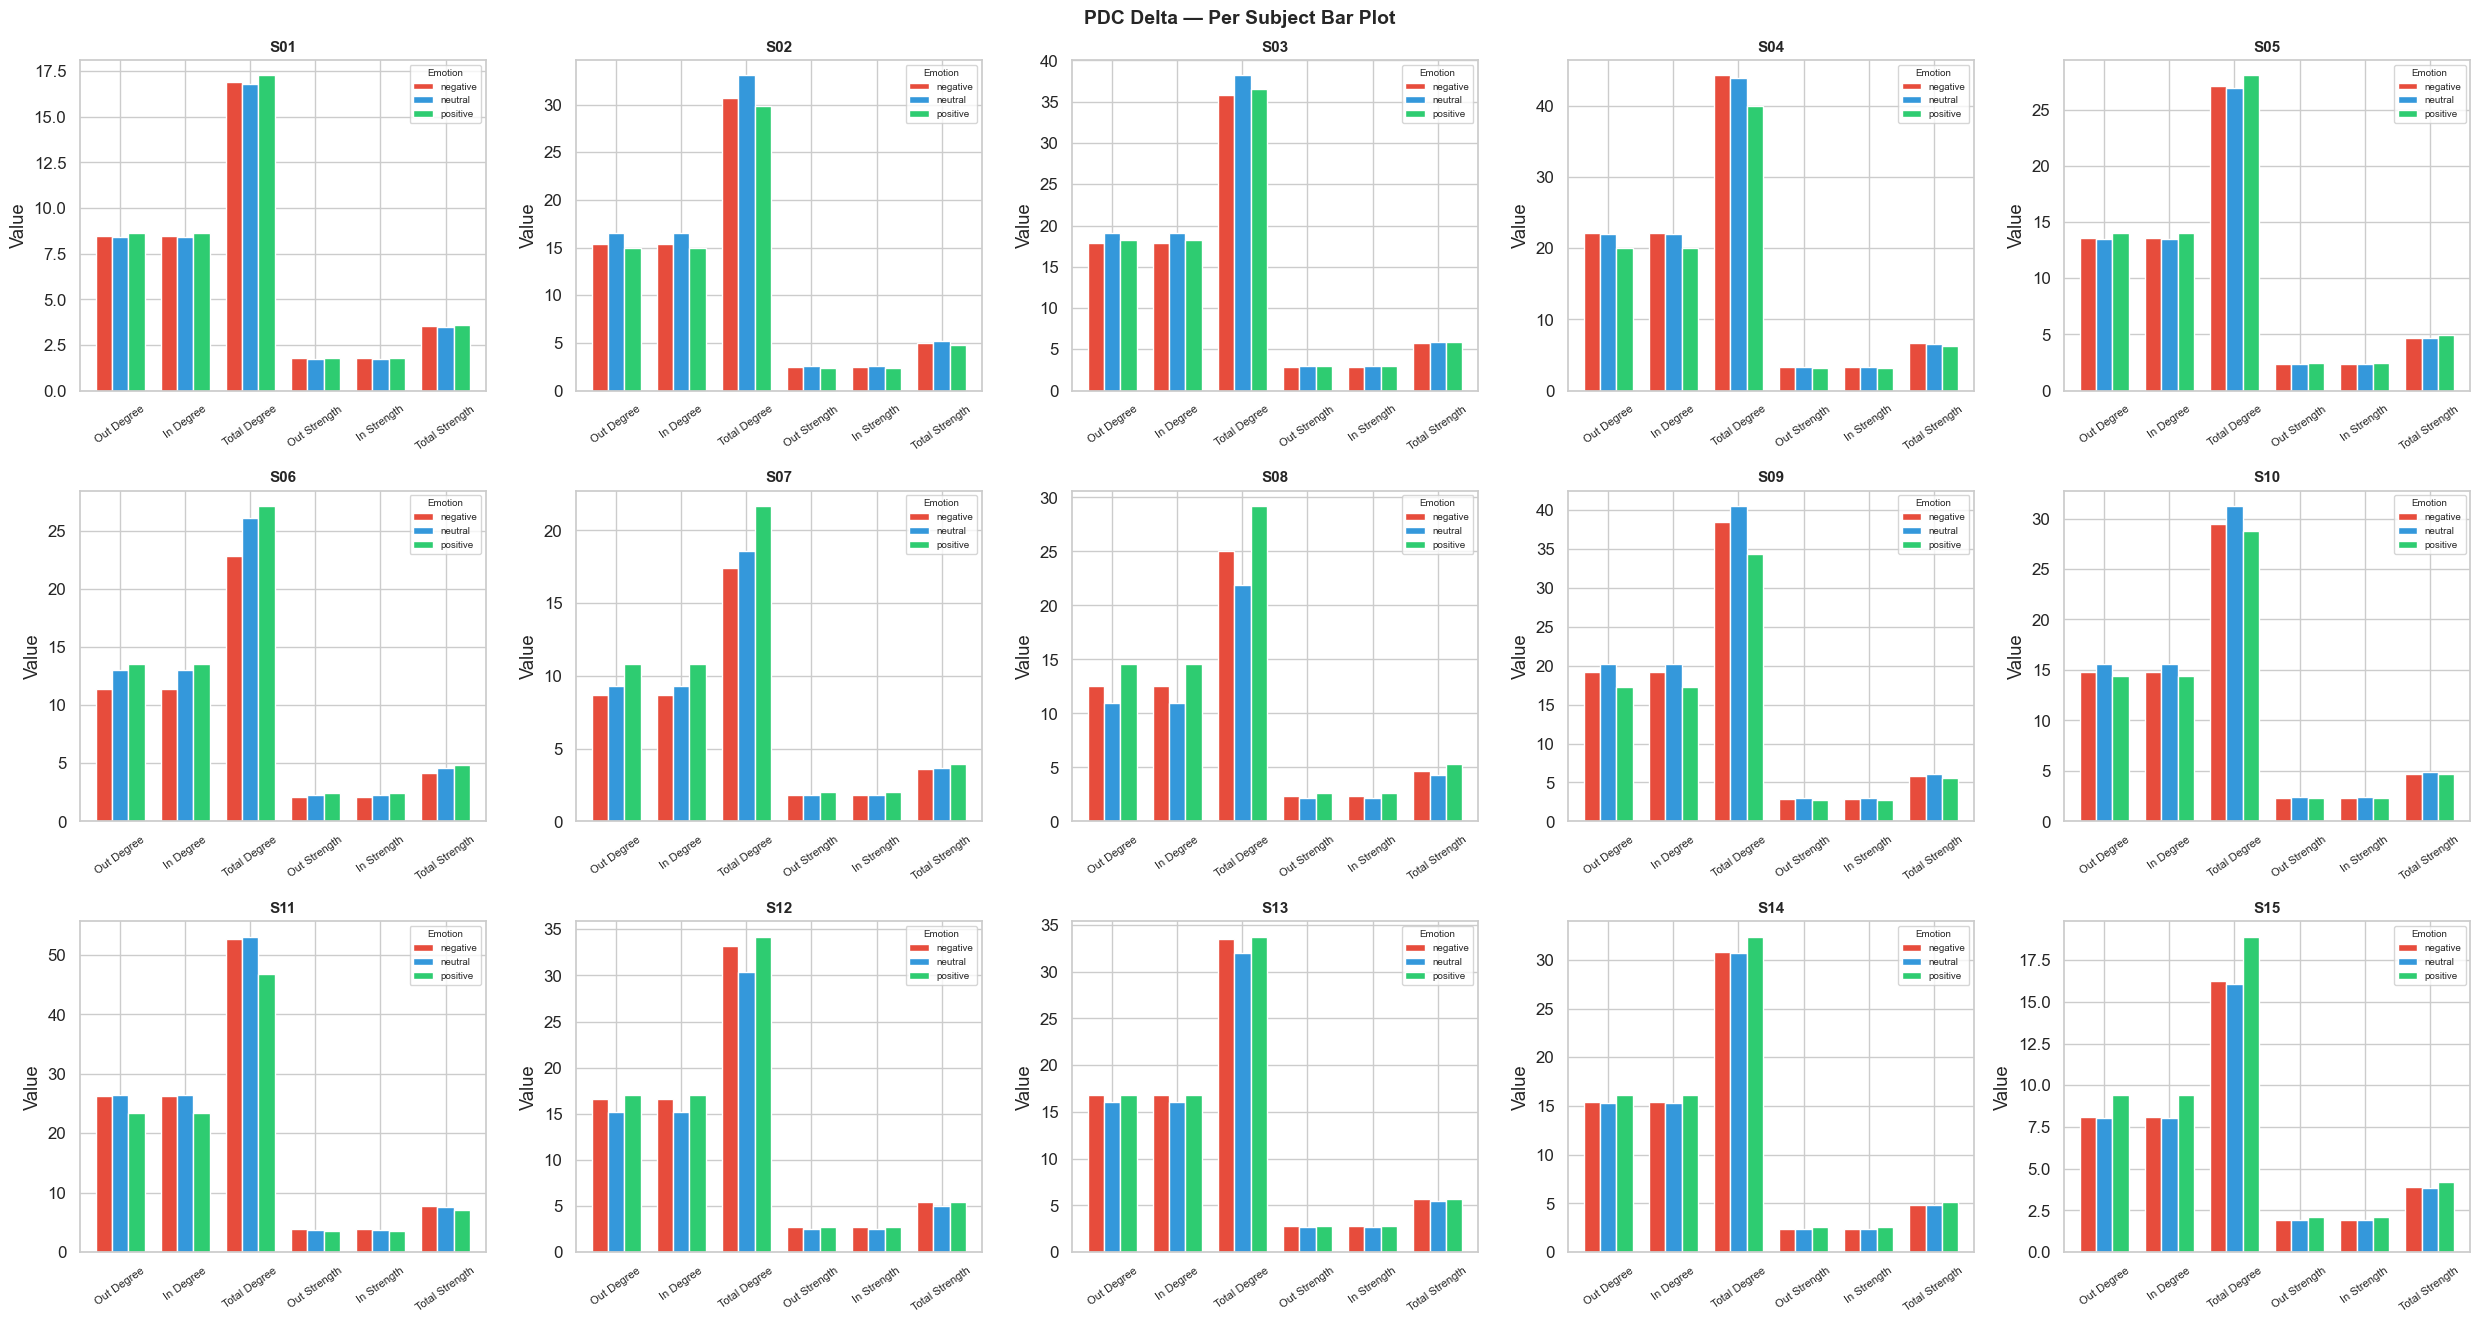


>>> Plotting: PDC Theta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_theta_subject_bars.png


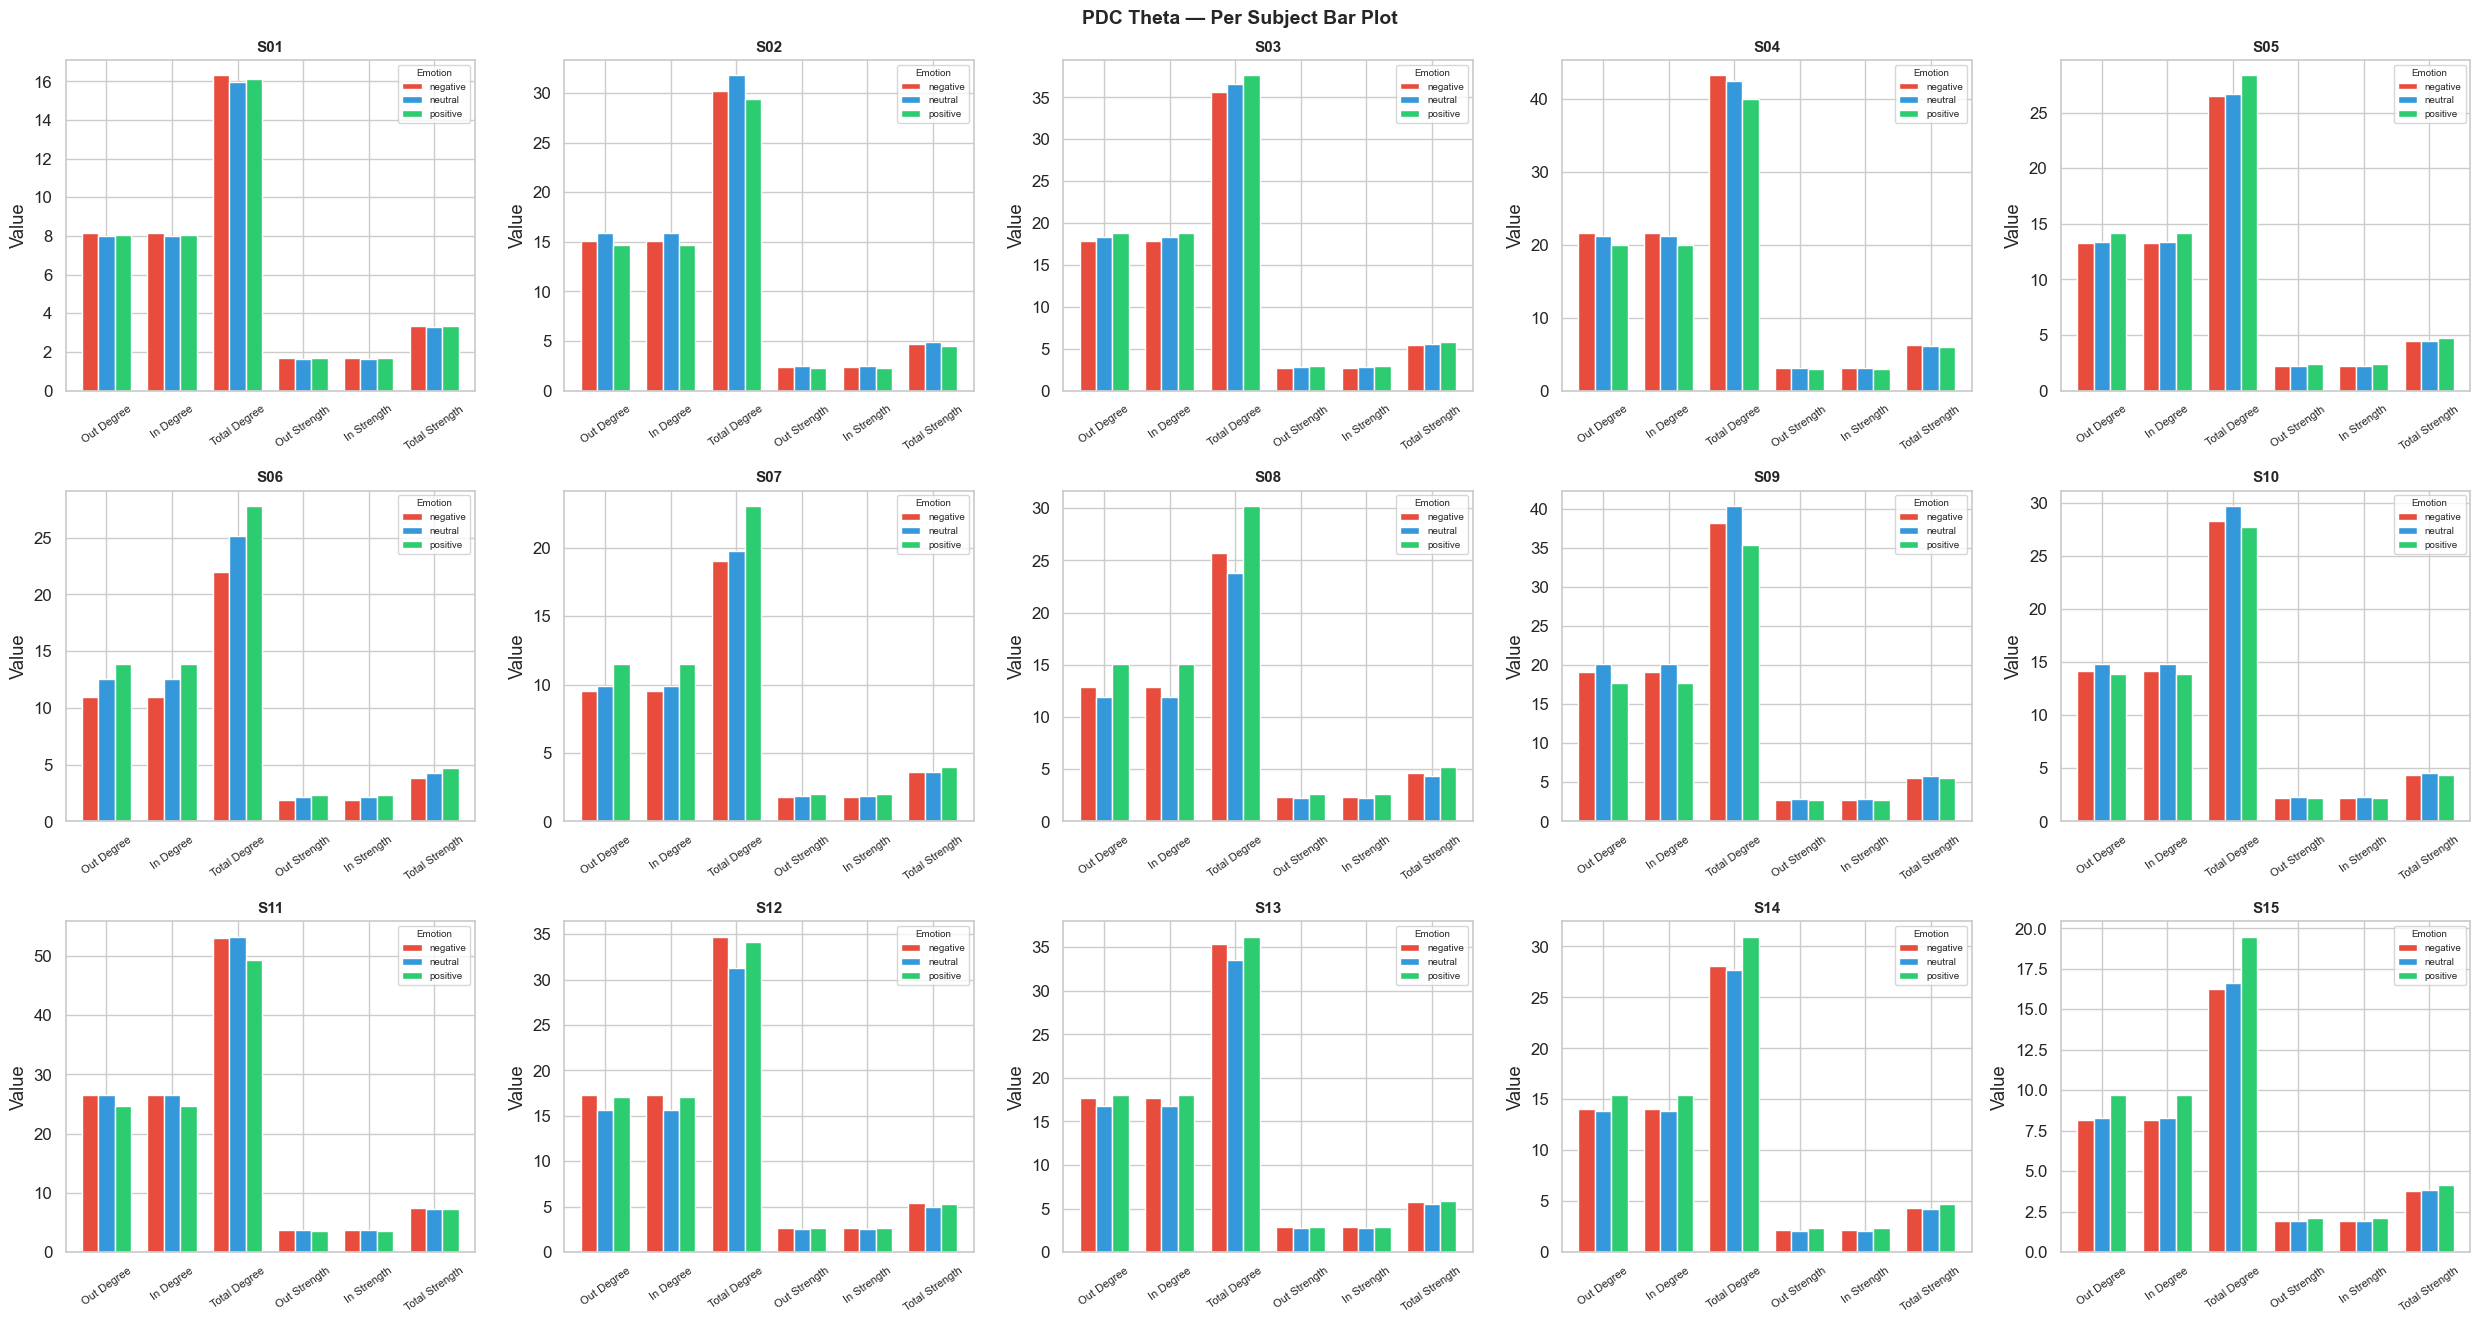


>>> Plotting: PDC Alpha
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_alpha_subject_bars.png


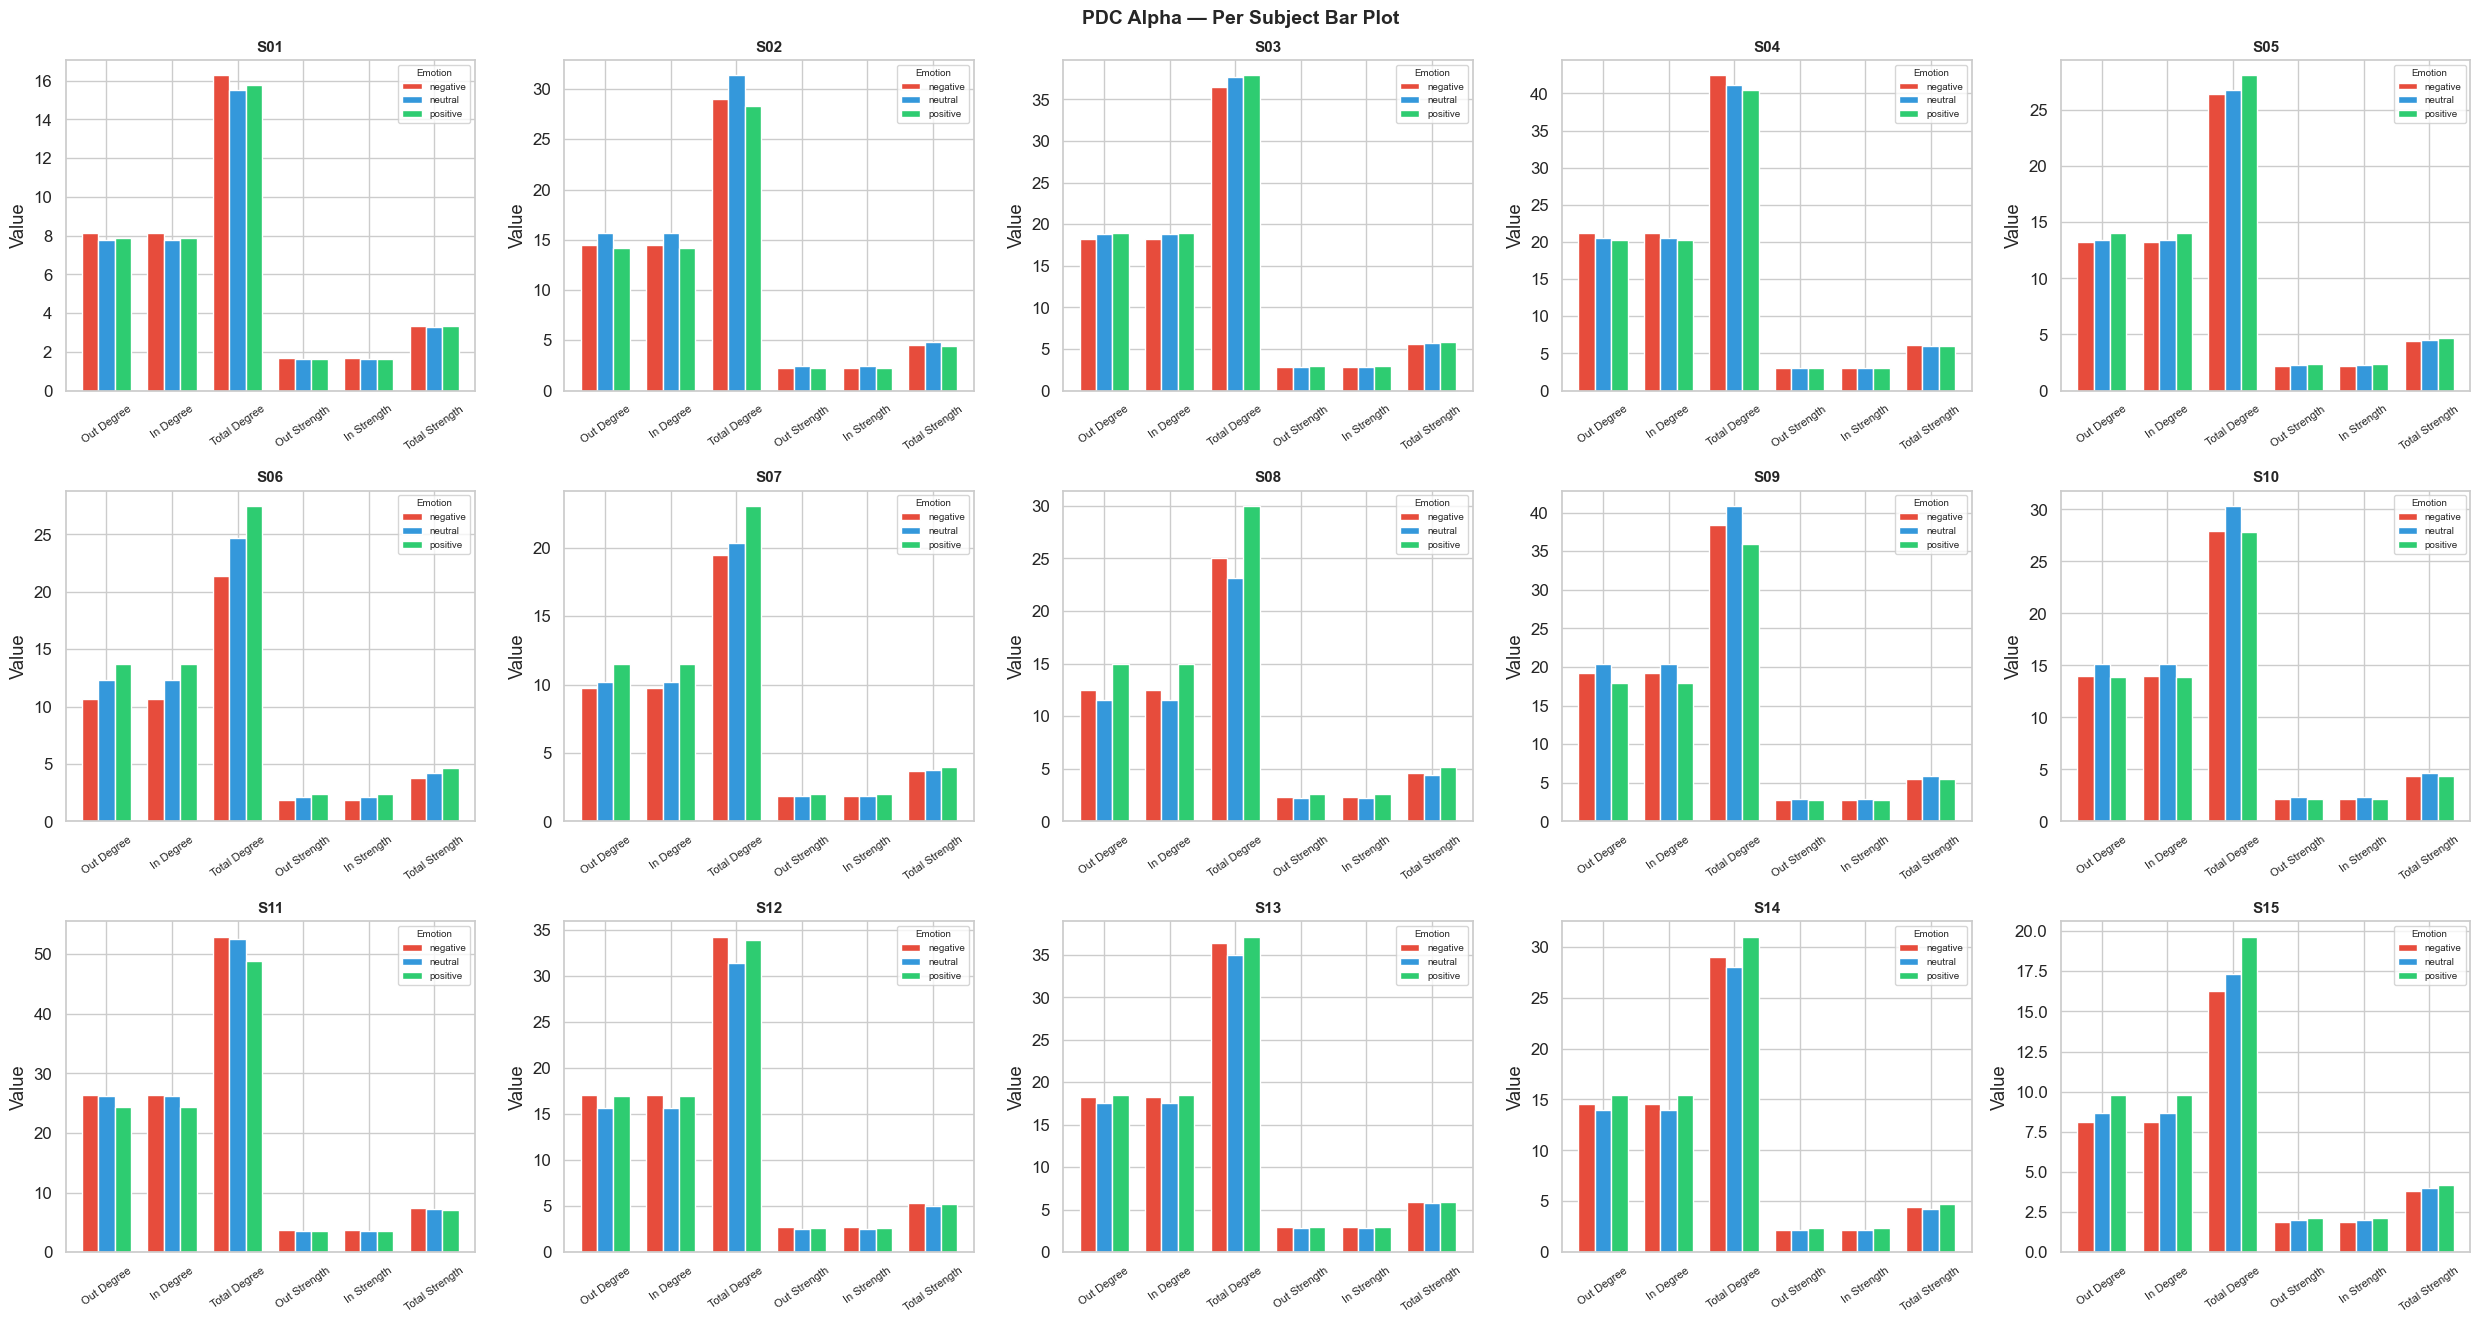


>>> Plotting: PDC Beta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_beta_subject_bars.png


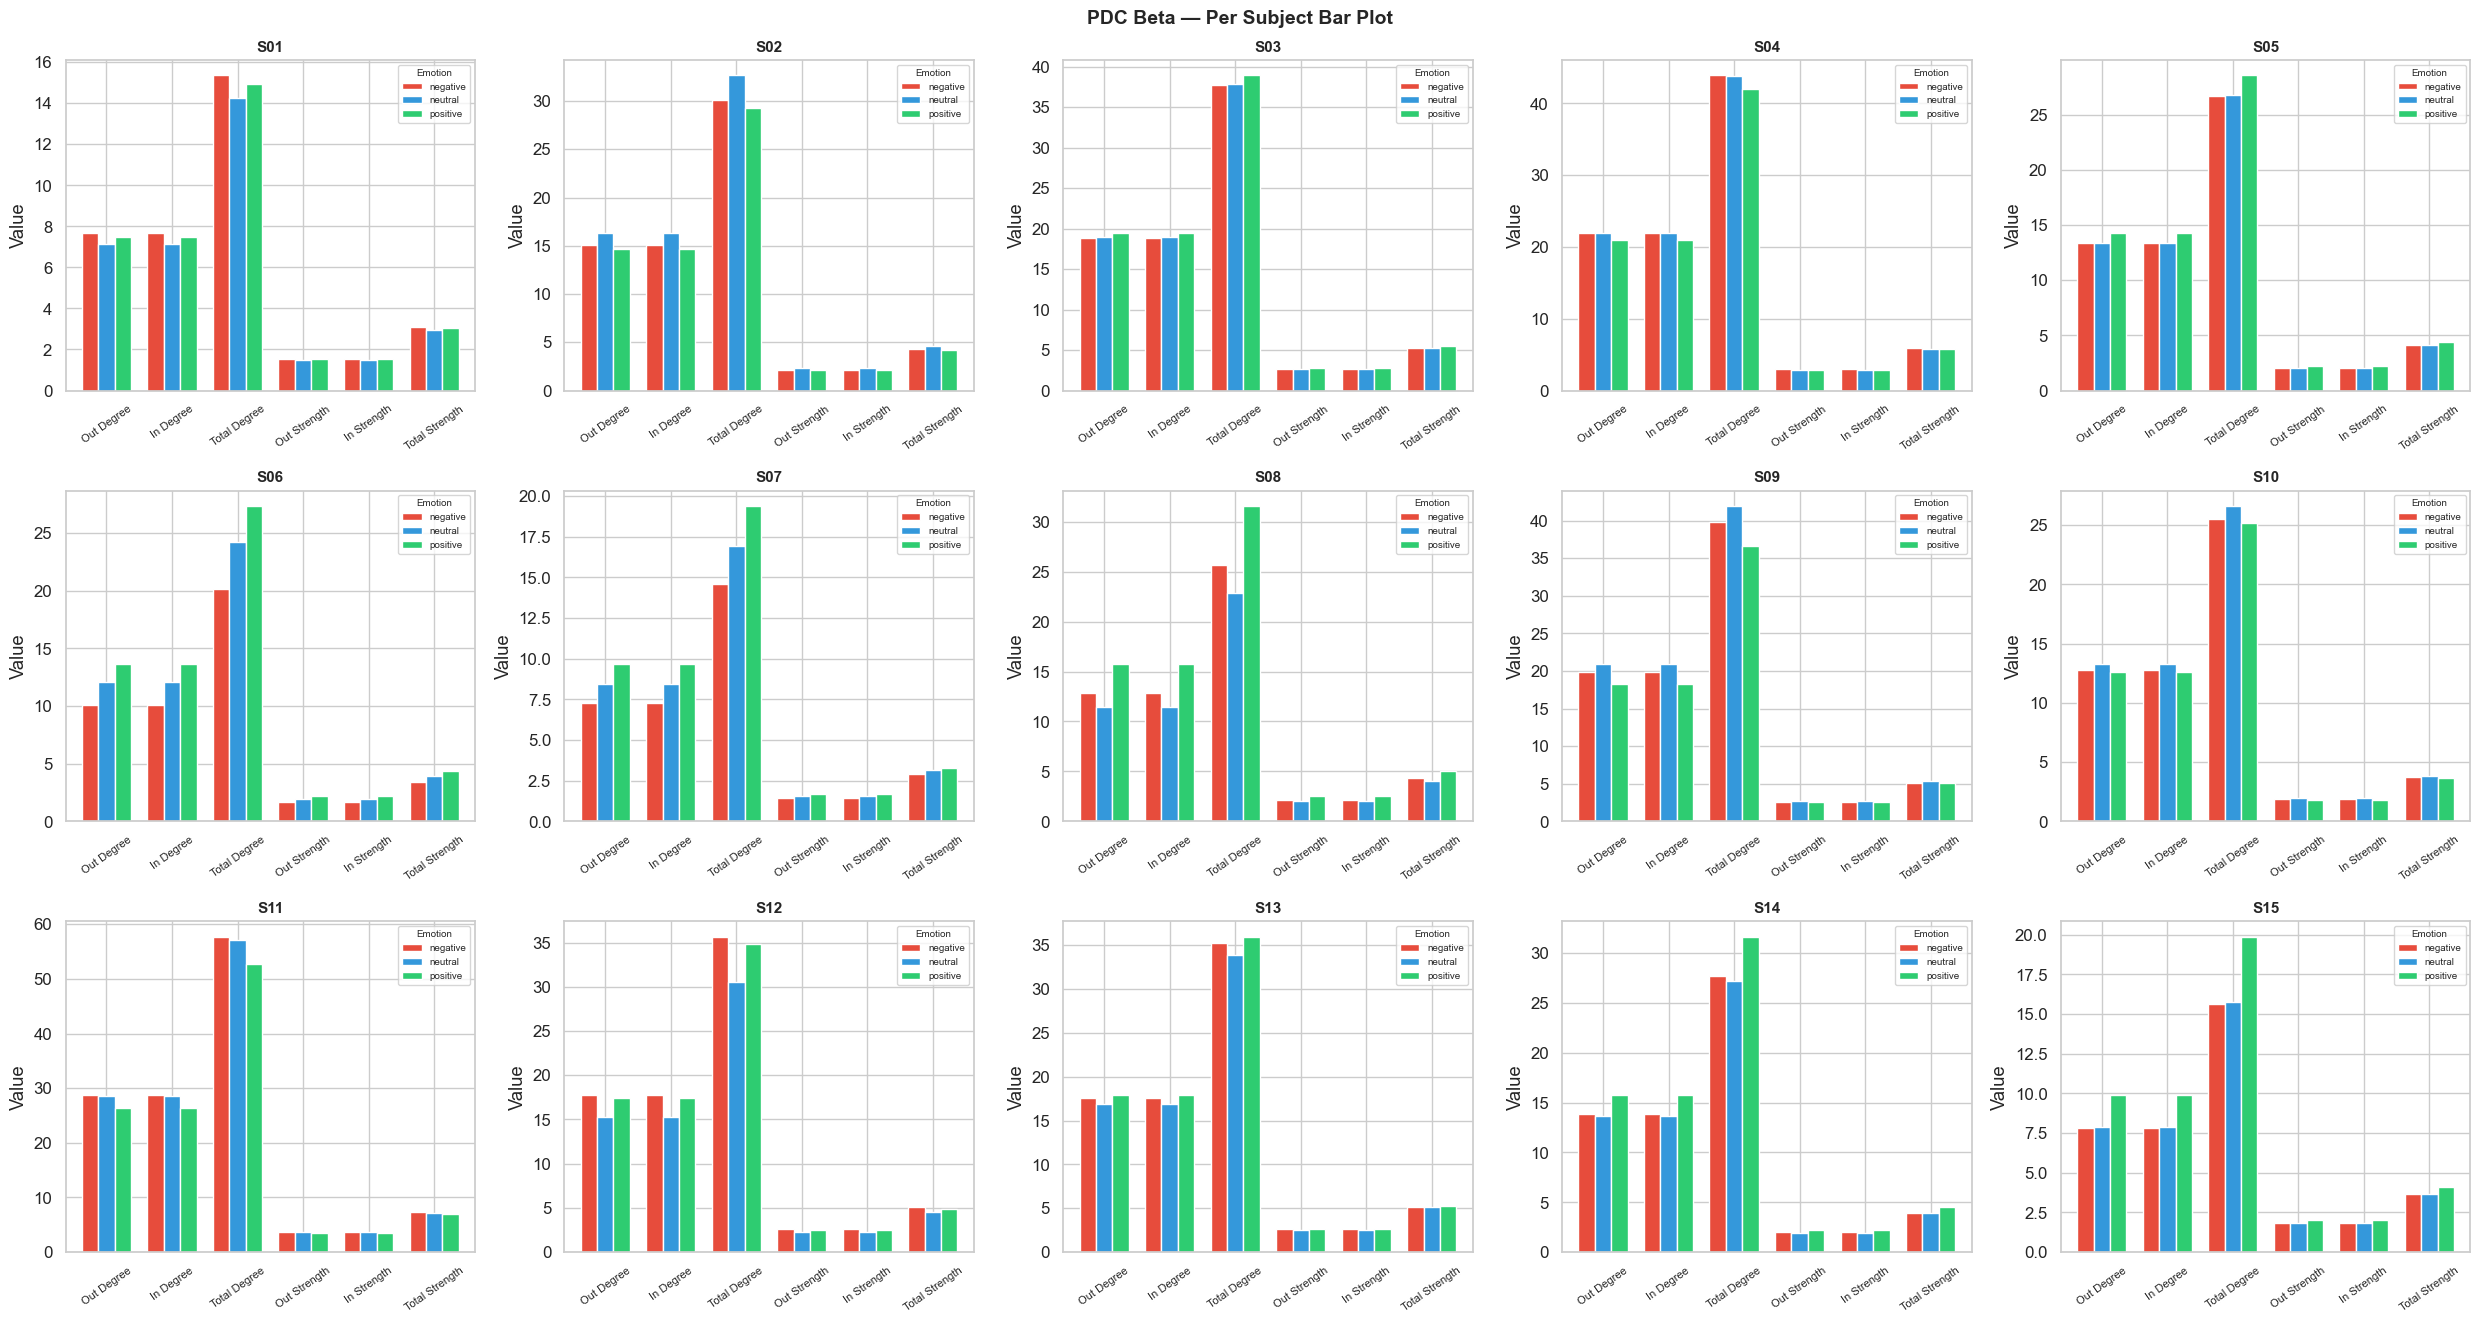


>>> Plotting: PDC Gamma
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_gamma_subject_bars.png


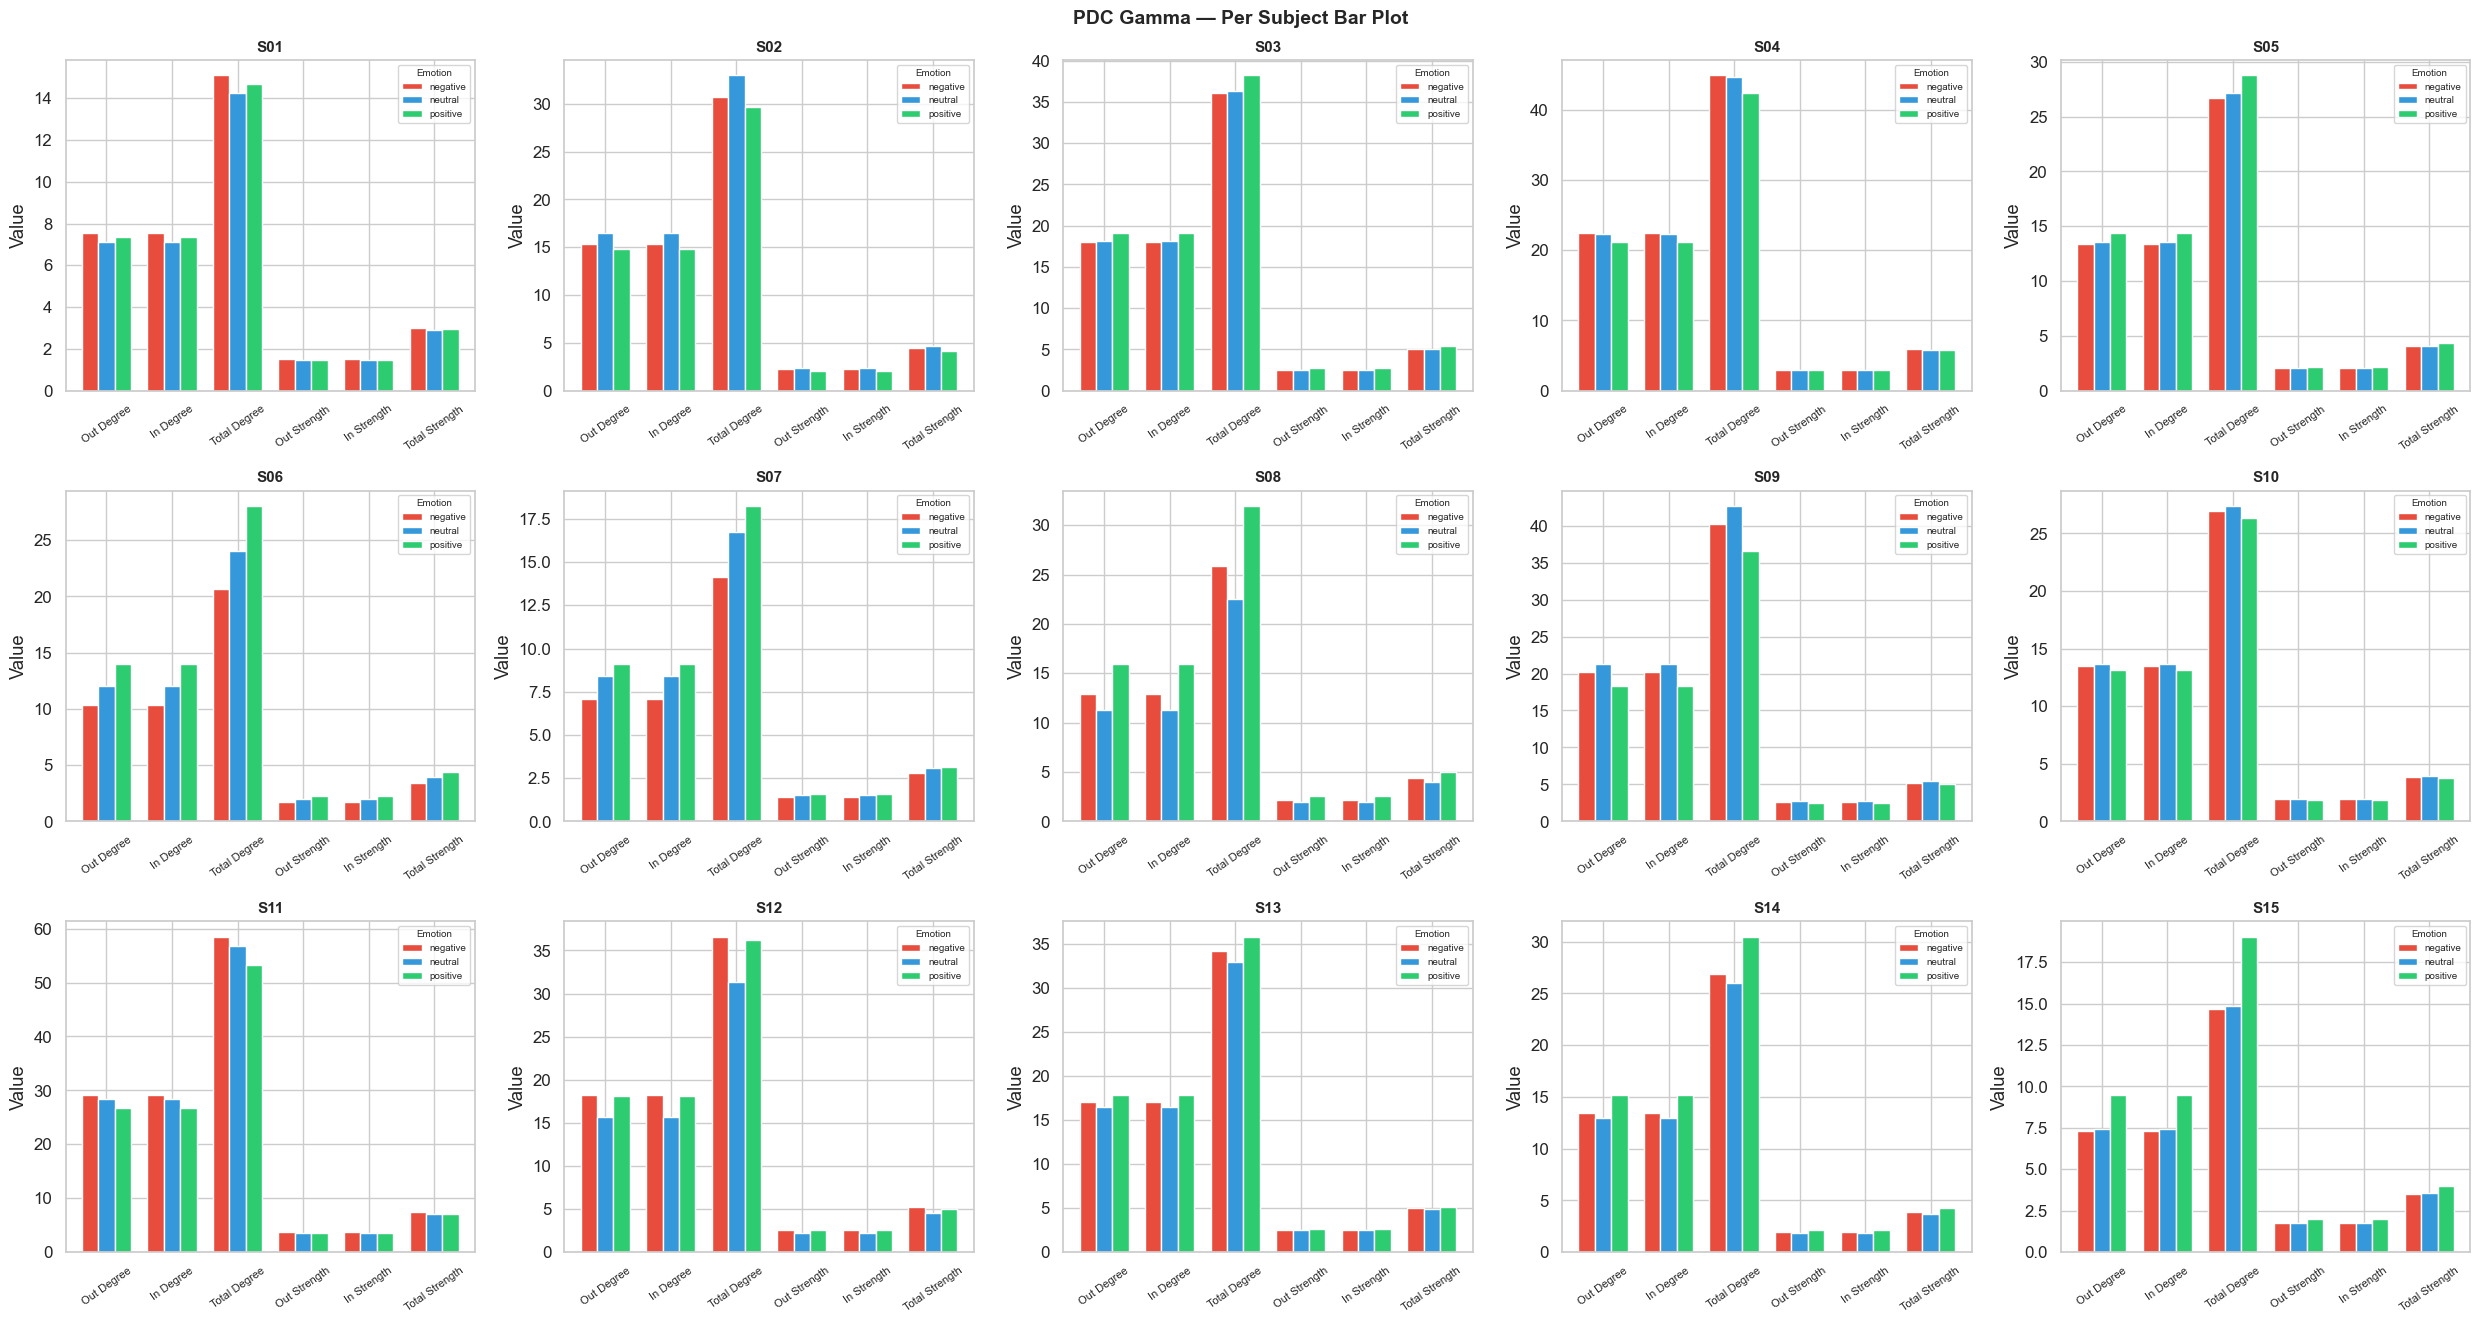


>>> Plotting: PDC Broadband
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_broadband_subject_bars.png


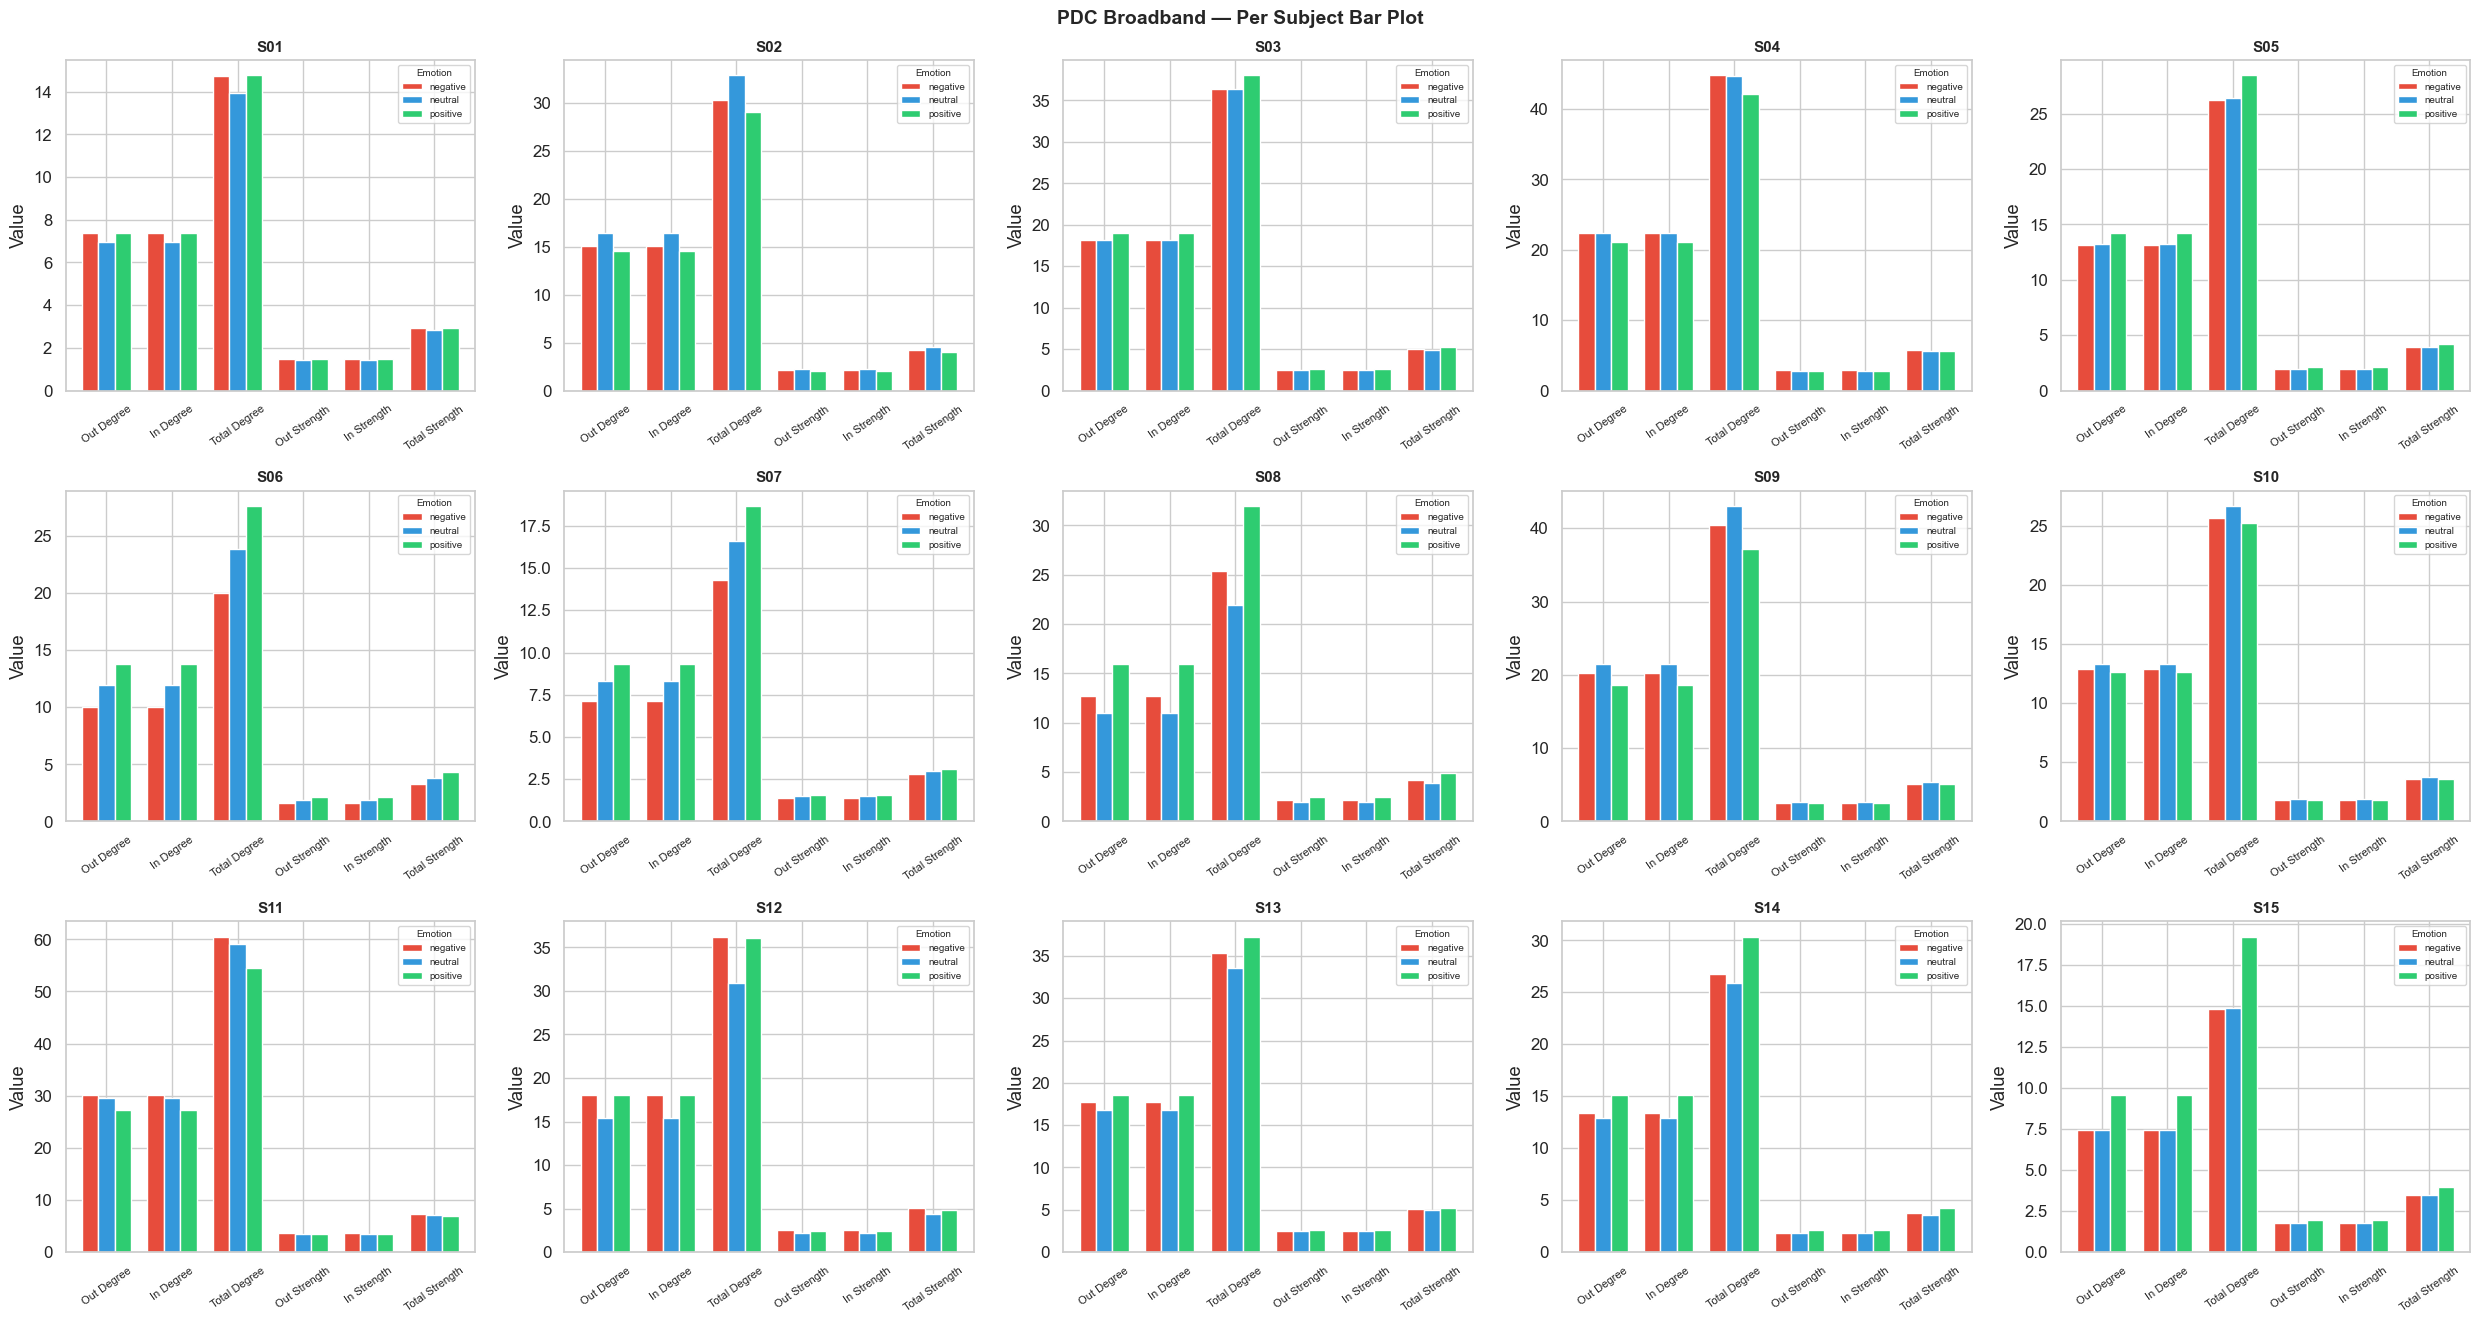

In [4]:
# ==============================================================================
# SECTION 3: BAR PLOT PER SUBJEK (6 metrik x 3 emosi)
# ==============================================================================
def plot_subject_bars(df, method_name, save_prefix):
    df_avg = df.groupby(['subject_id', CLASS_COL])[MEAN_COLS].mean().reset_index()
    subjects = sorted(df_avg['subject_id'].unique())
    
    ncols = 5
    nrows = int(np.ceil(len(subjects) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
    axes = axes.flatten()
    
    bar_colors = [PALETTE[e] for e in EMOTIONS]
    
    for i, subj in enumerate(subjects):
        ax = axes[i]
        subj_df = (
            df_avg[df_avg['subject_id'] == subj]
            .set_index(CLASS_COL)
            .reindex(EMOTIONS)[MEAN_COLS]
        )
        # Rename columns to short labels for readability
        subj_df.columns = [SHORT[c] for c in subj_df.columns]
        
        # Transpose: rows = metrics, columns = emotions
        subj_df.T.plot(kind='bar', ax=ax, color=bar_colors,
                       width=0.75, edgecolor='white')
        ax.set_title(subj, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=35, labelsize=8)
        ax.legend(EMOTIONS, fontsize=7, title='Emotion', title_fontsize=7)
    
    # Sembunyikan subplot kosong
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'{method_name} — Per Subject Bar Plot',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    path = FIG_DIR / f'{save_prefix}_subject_bars.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')
    plt.show()

for name, df in data.items():
    print(f'\n>>> Plotting: {name}')
    plot_subject_bars(df, name, name.lower().replace(' ', '_'))

---
## Section 4: Z-Score Heatmap (Deteksi Anomali Antar Subjek)
Menampilkan nilai Z-score setiap subjek relatif terhadap rata-rata kelompok pada tiap metrik.
Merah = jauh di atas rata-rata (hub), biru = jauh di bawah (lemah/terisolir).


>>> Plotting: GC
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\gc_zscore_heatmap.png


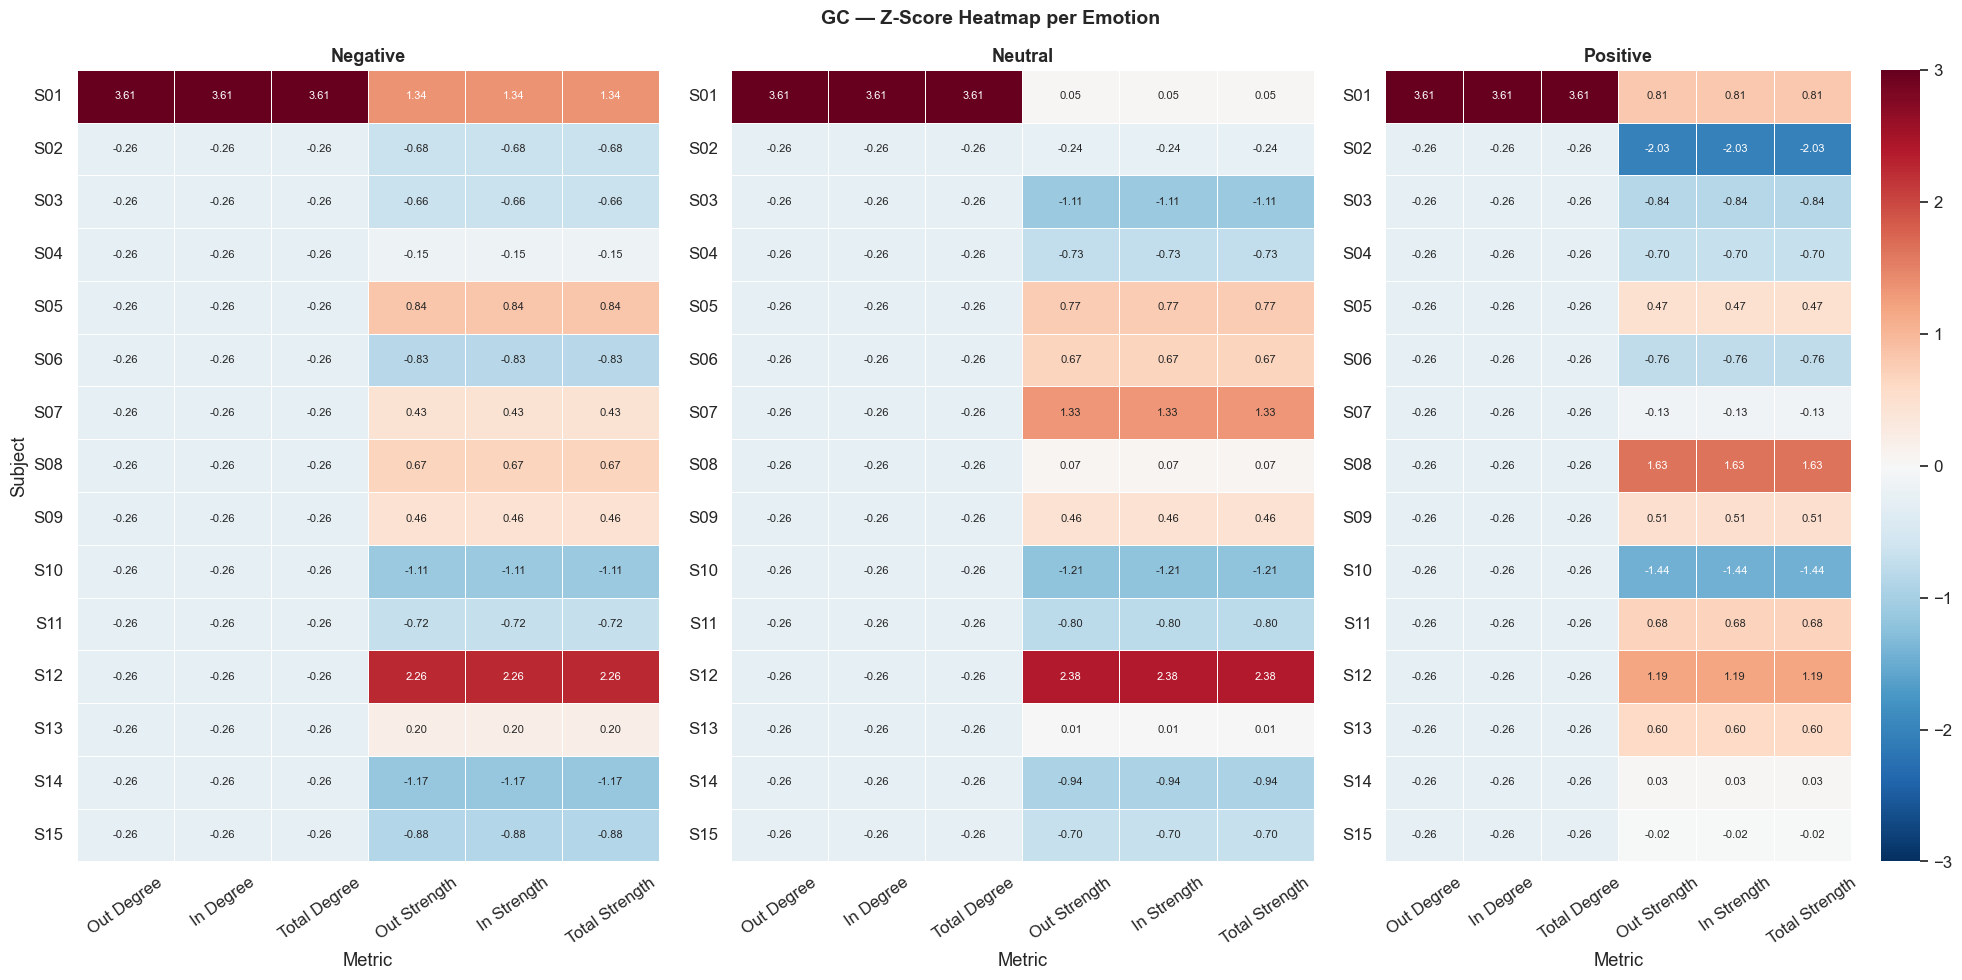


>>> Plotting: PDC Delta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_delta_zscore_heatmap.png


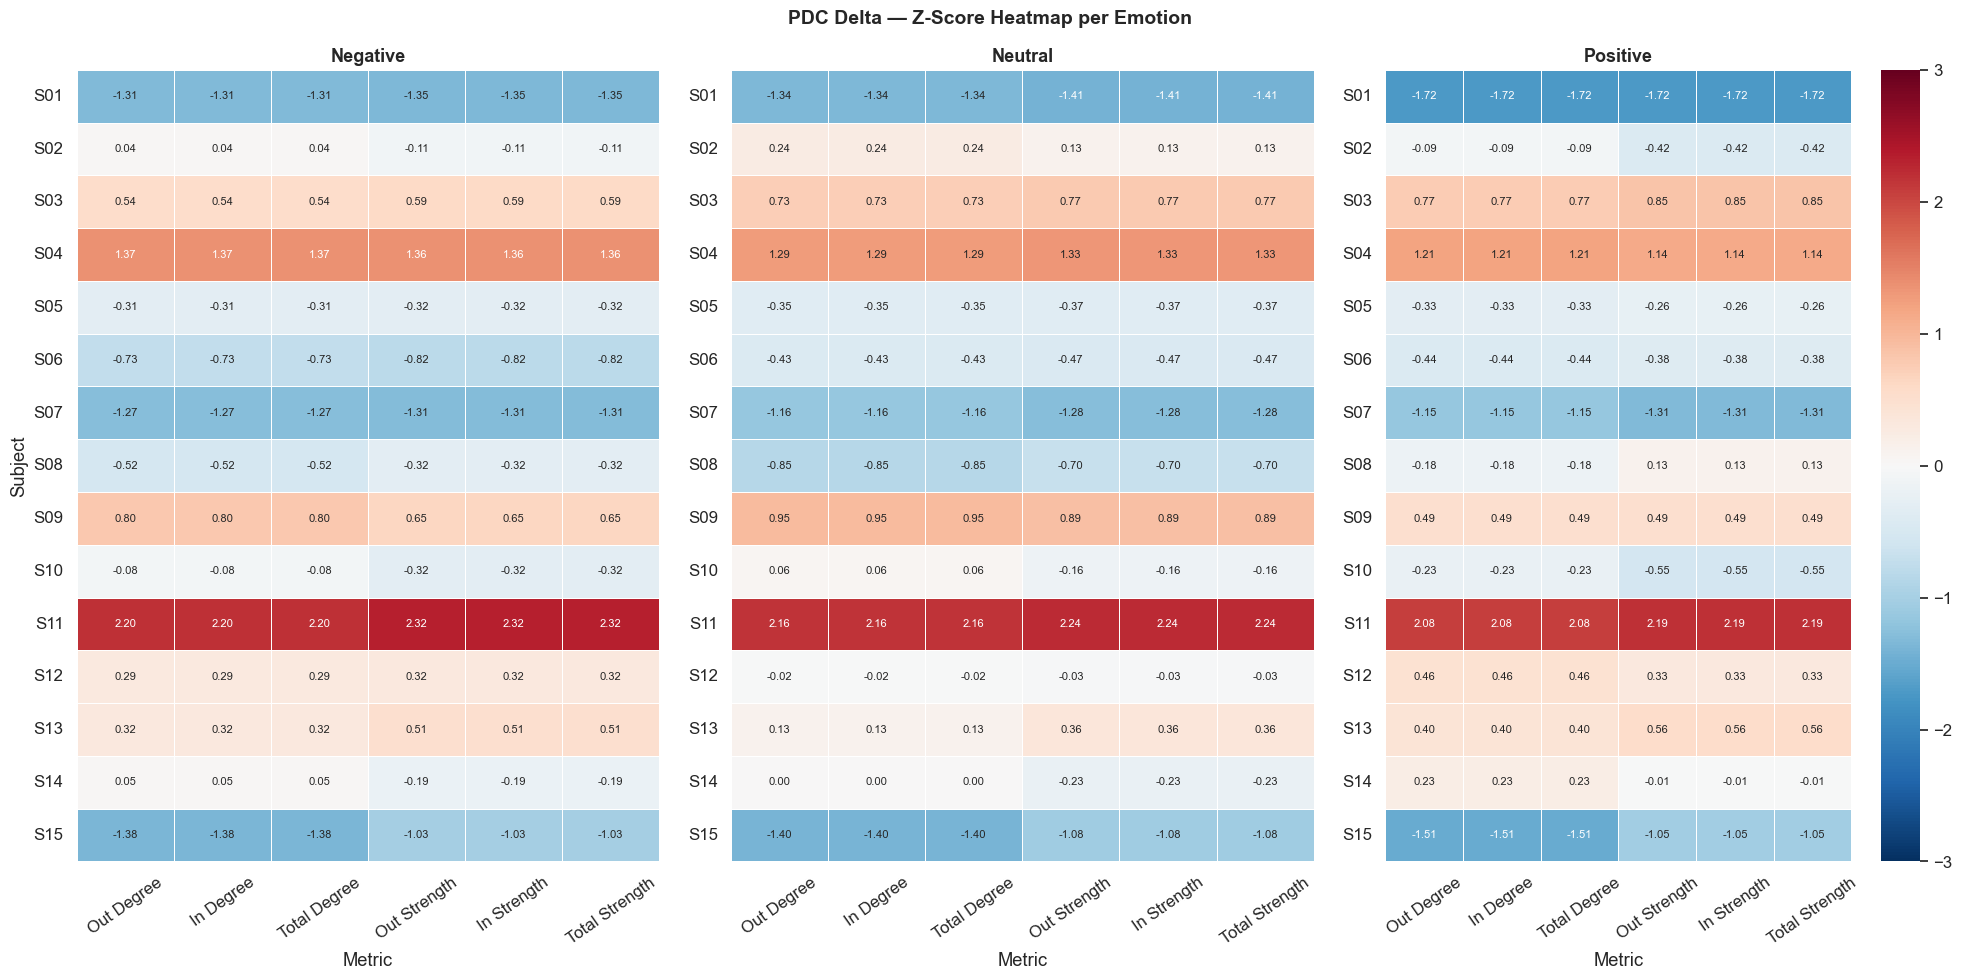


>>> Plotting: PDC Theta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_theta_zscore_heatmap.png


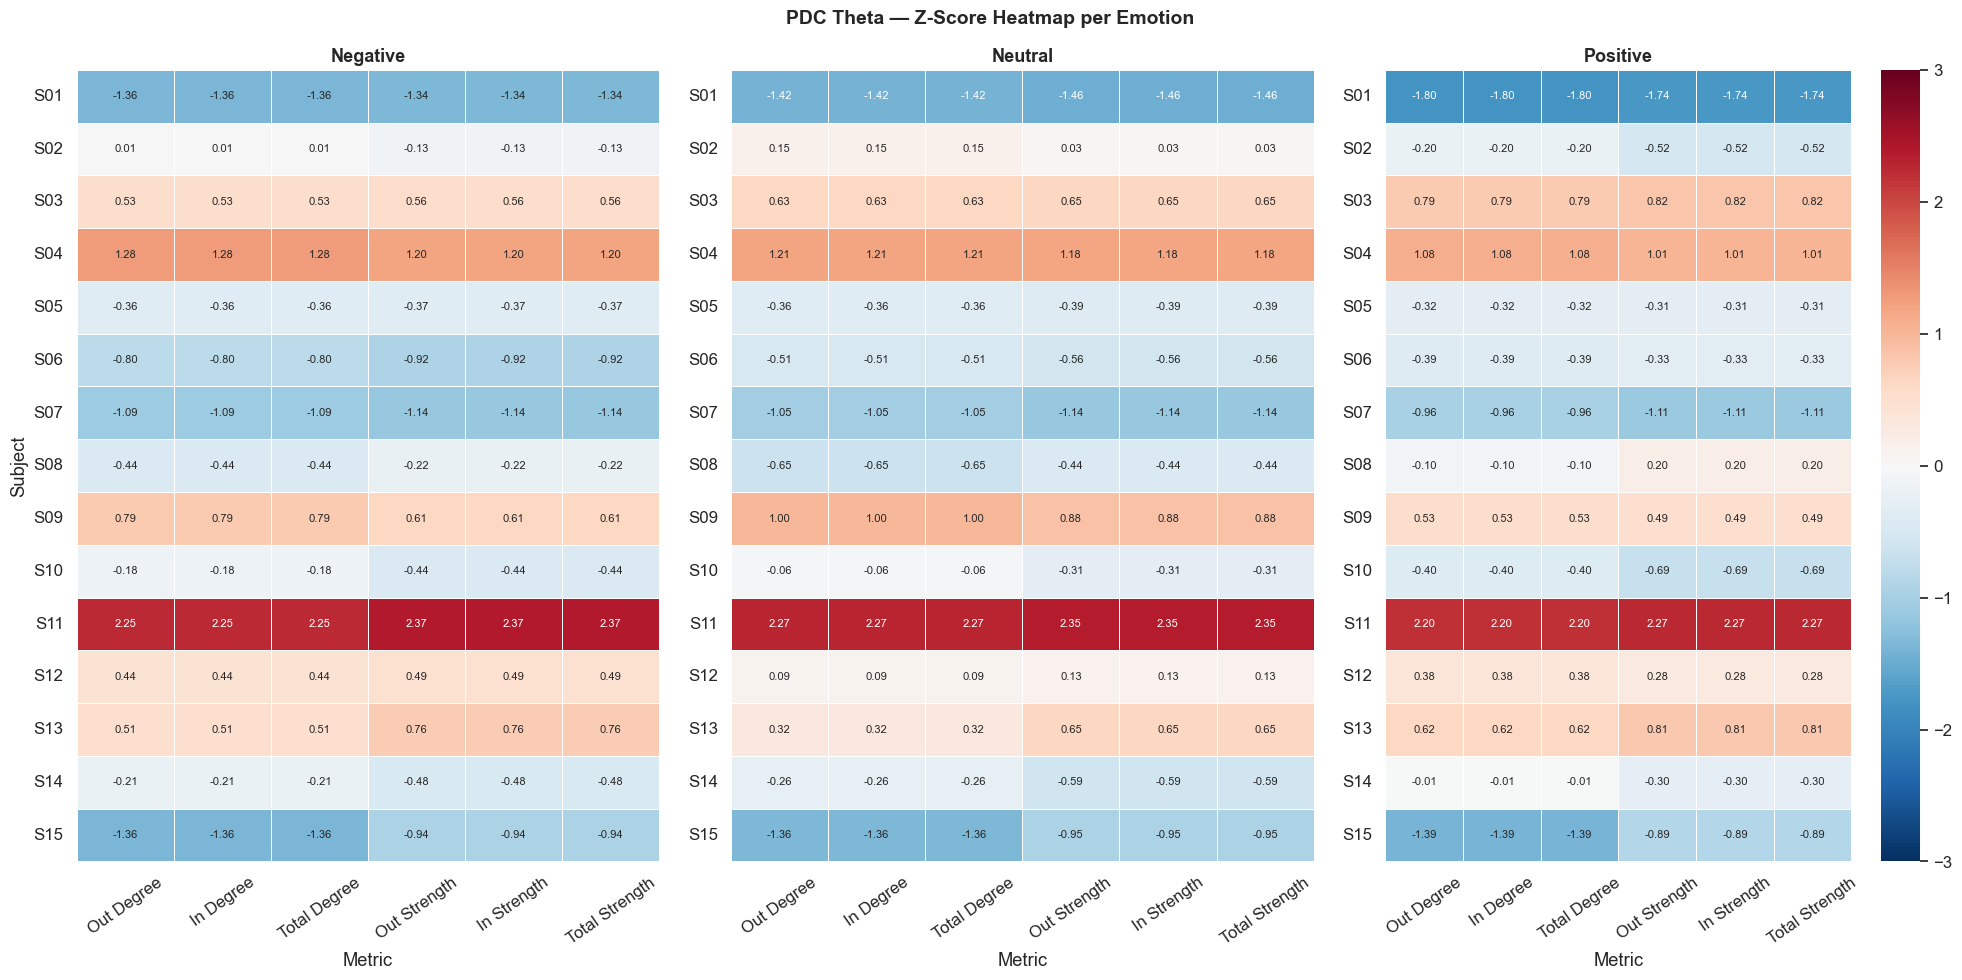


>>> Plotting: PDC Alpha
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_alpha_zscore_heatmap.png


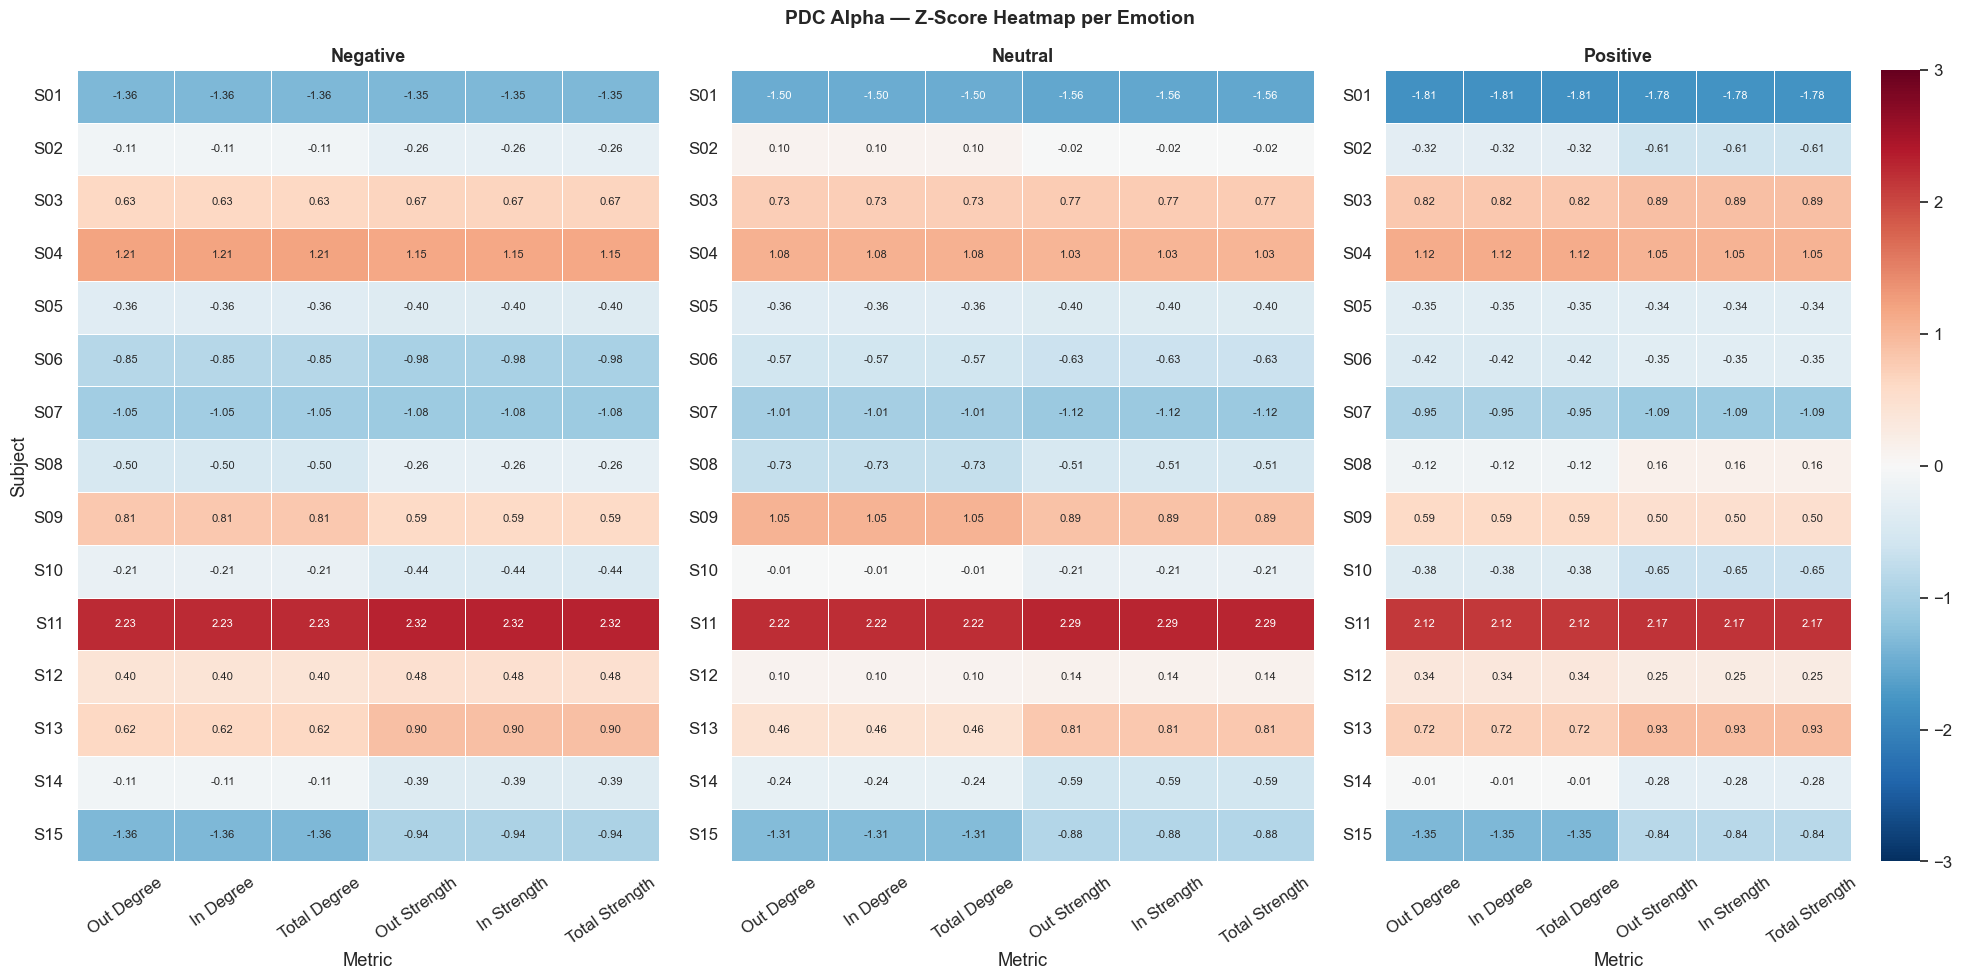


>>> Plotting: PDC Beta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_beta_zscore_heatmap.png


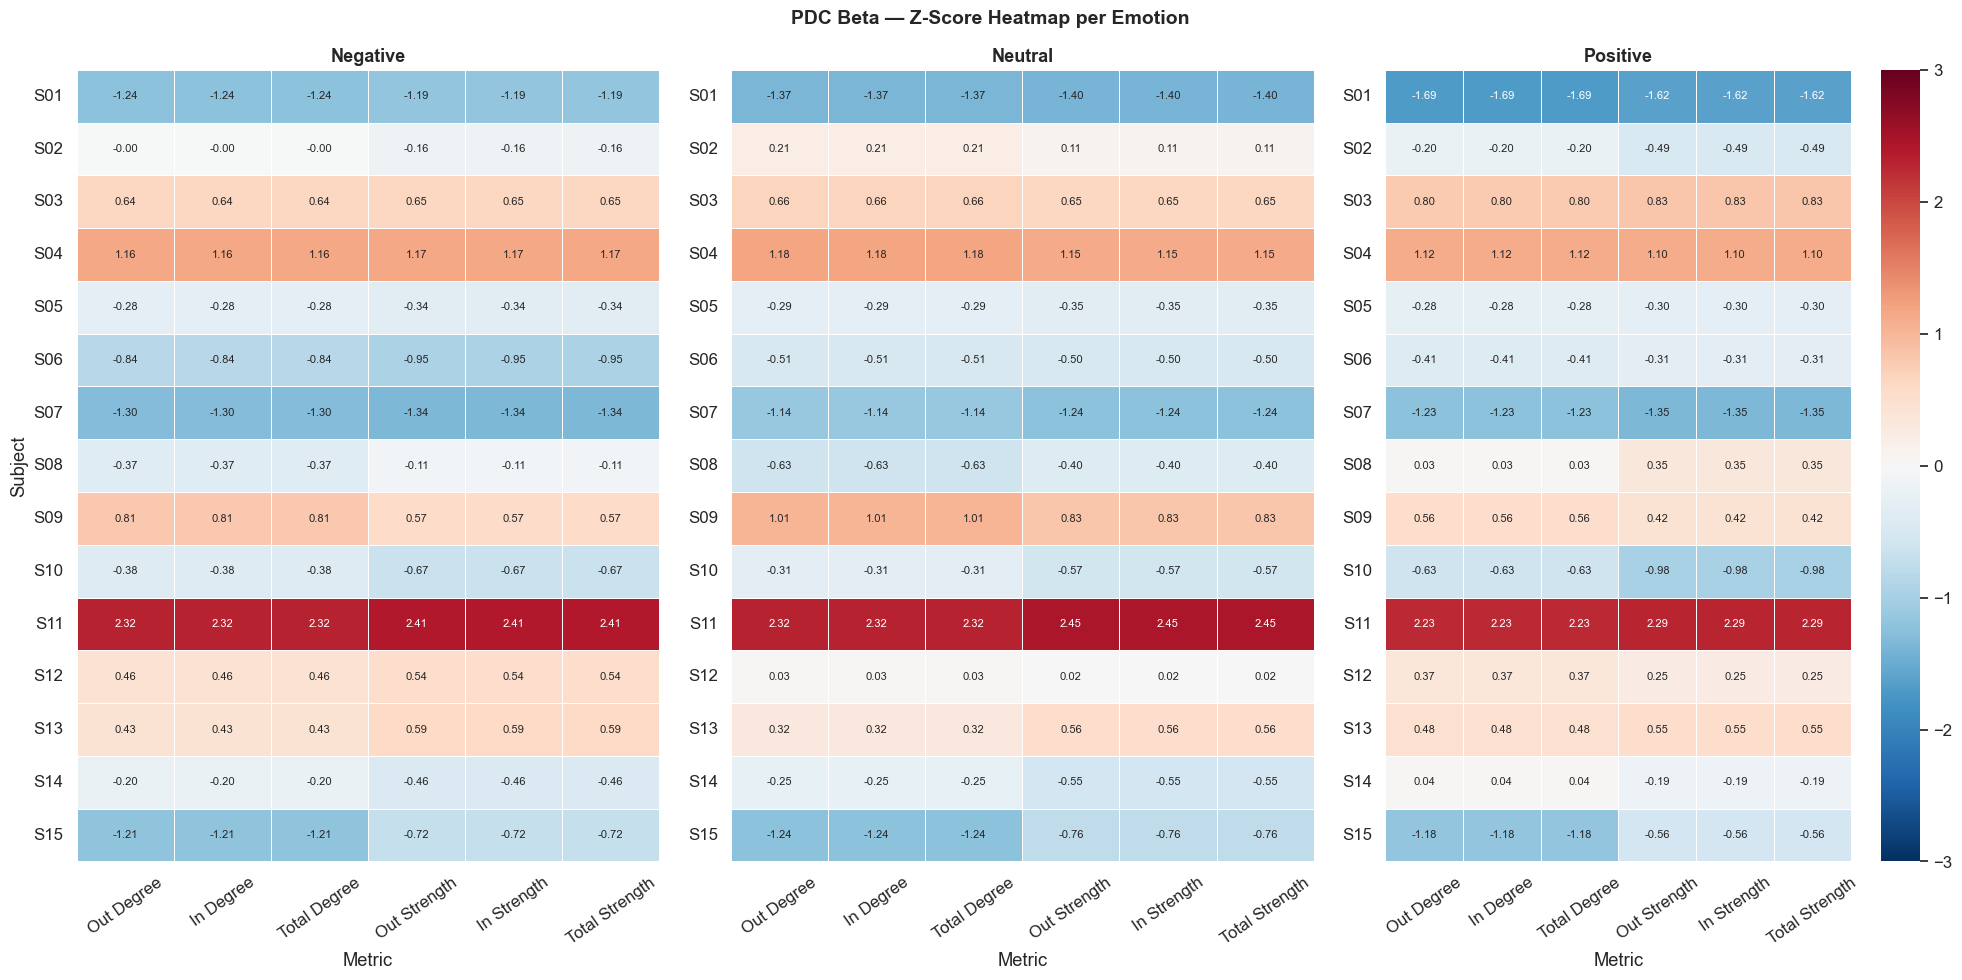


>>> Plotting: PDC Gamma
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_gamma_zscore_heatmap.png


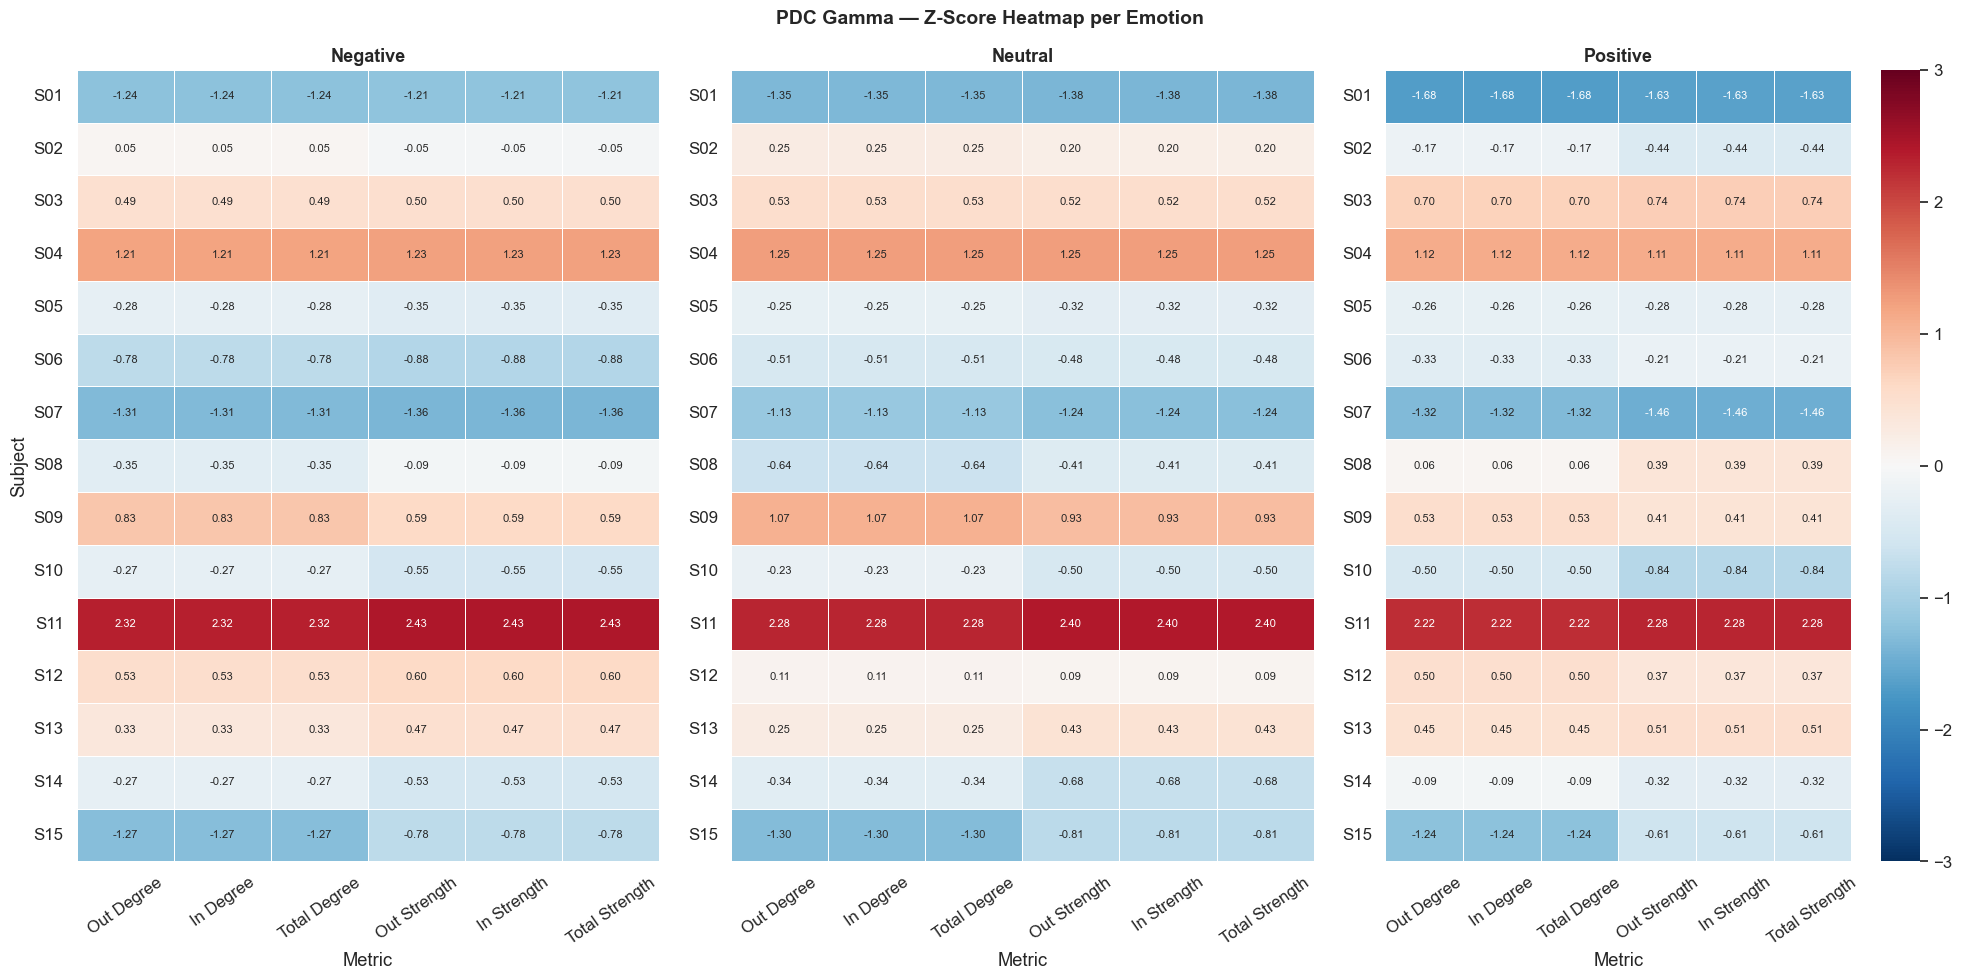


>>> Plotting: PDC Broadband
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\figures\pdc_broadband_zscore_heatmap.png


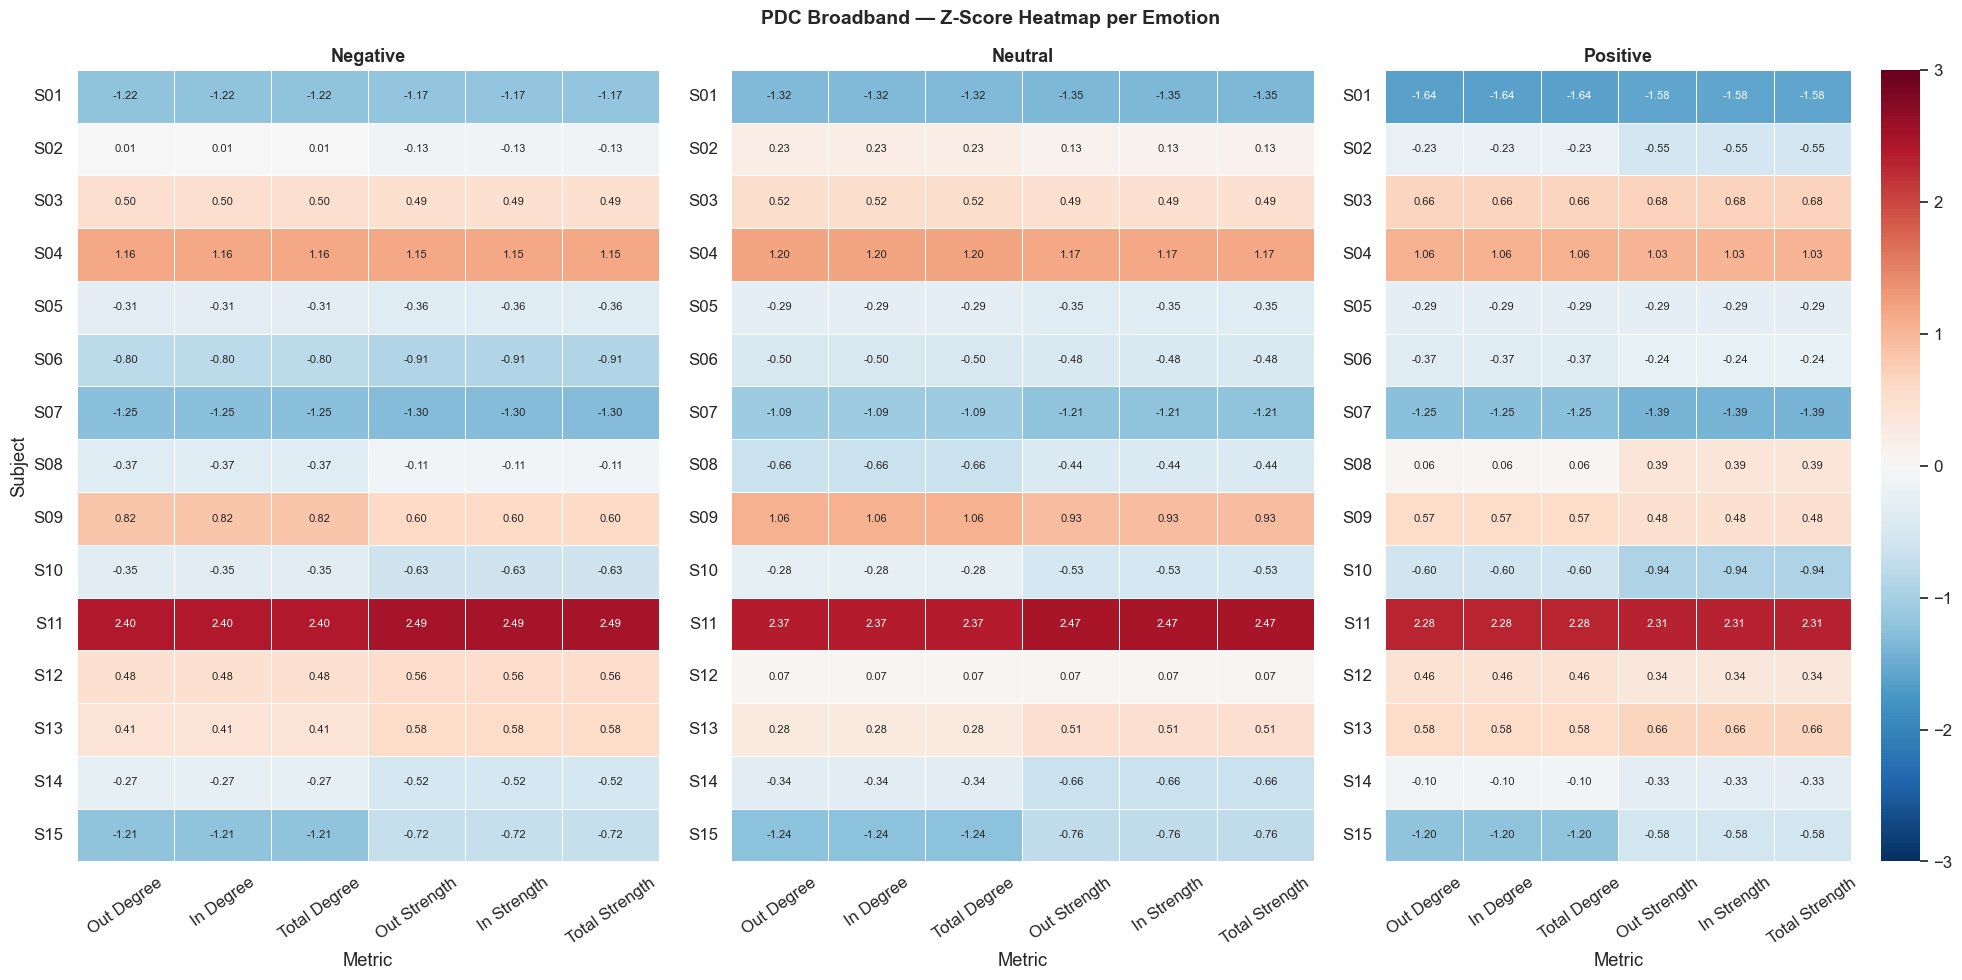

In [5]:
# ==============================================================================
# SECTION 4: Z-SCORE HEATMAP (subjek x metrik, per emosi)
# ==============================================================================
def plot_zscore_heatmap(df, method_name, save_prefix):
    df_avg = df.groupby(['subject_id', CLASS_COL])[MEAN_COLS].mean().reset_index()
    
    # Figure is placed at full \textwidth in the thesis; fonts are sized
    # for that print width rather than for a full-screen preview.
    fig, axes = plt.subplots(1, 3, figsize=(24, 12))
    
    for idx, emotion in enumerate(EMOTIONS):
        ax = axes[idx]
        subset = (
            df_avg[df_avg[CLASS_COL] == emotion]
            .set_index('subject_id')[MEAN_COLS]
            .sort_index()
        )
        subset.columns = [SHORT[c] for c in subset.columns]
        
        # Z-score normalisasi
        z = (subset - subset.mean()) / (subset.std() + 1e-10)
        
        sns.heatmap(z, ax=ax, annot=True, fmt='.2f',
                    cmap='RdBu_r', vmin=-3, vmax=3, center=0,
                    linewidths=0.8, annot_kws={'size': 15},
                    cbar=(idx == 2), cbar_kws={'shrink': 0.85} if idx == 2 else None)
        if idx == 2:
            ax.collections[0].colorbar.ax.tick_params(labelsize=18)
        
        ax.set_title(f'{emotion.capitalize()}', fontsize=26, fontweight='bold')
        ax.set_xlabel('Metric', fontsize=20)
        ax.set_ylabel('Subject' if idx == 0 else '', fontsize=20)
        ax.tick_params(axis='y', rotation=0, labelsize=17)
        ax.tick_params(axis='x', rotation=35, labelsize=17)
    
    fig.suptitle(f'{method_name} — Z-Score Heatmap per Emotion',
                 fontsize=30, fontweight='bold')
    plt.tight_layout()
    
    path = FIG_DIR / f'{save_prefix}_zscore_heatmap.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')
    plt.show()

for name, df in data.items():
    print(f'\n>>> Plotting: {name}')
    plot_zscore_heatmap(df, name, name.lower().replace(' ', '_'))

---
## Section 5: Simpan Tabel Statistik Individual (CSV)
Menghitung **mean ± std per subjek per kelas emosi** untuk semua metrik dan menyimpan hasilnya sebagai berkas CSV ke folder `output/`.

In [6]:
# ==============================================================================
# SECTION 5: SIMPAN STATISTIK INDIVIDUAL KE CSV
# ==============================================================================
def compute_individual_stats(df, name):
    stats = df.groupby(['subject_id', CLASS_COL])[MEAN_COLS].agg(['mean', 'std'])
    stats.columns = ['_'.join(col) for col in stats.columns]
    stats = stats.reset_index()
    
    fname = f'individual_stats_{name.lower().replace(" ", "_")}.csv'
    stats.to_csv(OUTPUT_DIR / fname, index=False)
    print(f'  Saved: {fname} ({stats.shape[0]} rows x {stats.shape[1]} cols)')
    return stats

print('=== Saving Individual Statistics Tables ===')
for name, df in data.items():
    compute_individual_stats(df, name)

print('\nDone! All files saved to:', OUTPUT_DIR)

=== Saving Individual Statistics Tables ===
  Saved: individual_stats_gc.csv (45 rows x 14 cols)
  Saved: individual_stats_pdc_delta.csv (45 rows x 14 cols)
  Saved: individual_stats_pdc_theta.csv (45 rows x 14 cols)
  Saved: individual_stats_pdc_alpha.csv (45 rows x 14 cols)
  Saved: individual_stats_pdc_beta.csv (45 rows x 14 cols)
  Saved: individual_stats_pdc_gamma.csv (45 rows x 14 cols)
  Saved: individual_stats_pdc_broadband.csv (45 rows x 14 cols)

Done! All files saved to: D:\Skripsi\new_data\phase_2_statistics\2.1_individual_analysis\output
